# SHAP

In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from ARX import ARXPipeline
import re

INFO:ARX:Pipeline loaded from ./data/arx_pipeline.pkl


Loaded successfully
Available feature sets: ['circ', 'roberta', 'symptom', 'fusion']
Fusion model keys: ['valence_model', 'arousal_model', 'features', 'data']
Fusion features: 33 features
Training data shape: (7397, 54)
Training data columns: ['user_id', 'week', 'valence_w', 'arousal_w', 'radius_w', 'posts_true', 'anx_score', 'dep_score', 'ptsd_score', 'mania_score', 'sui_score', 'anx_label', 'dep_label', 'ptsd_label', 'mania_label', 'sui_label', 'empath_anxiety_mean_z', 'empath_pain_mean_z', 'empath_violence_mean_z', 'empath_sadness_mean_z', 'empath_depression_mean_z', 'empath_help_mean_z', 'empath_love_mean_z', 'empath_suffering_mean_z', 'empath_health_mean_z', 'empath_contentment_mean_z', 'empath_fear_mean_z', 'empath_trust_mean_z', 'empath_hate_mean_z', 'empath_therapy_mean_z', 'empath_sleep_mean_z', 'empath_anger_mean_z', 'empath_shame_mean_z', 'empath_optimism_mean_z', 'v_hat_mean', 'a_hat_mean', 'r_hat_mean', 'v_true_mean', 'a_true_mean', 'r_true_mean', 'v_true_mean_rm2', 'v_tru

/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_28409/2964310057.py:105: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_v, X_shap, feature_names=fusion_features, show=False, max_display=20)


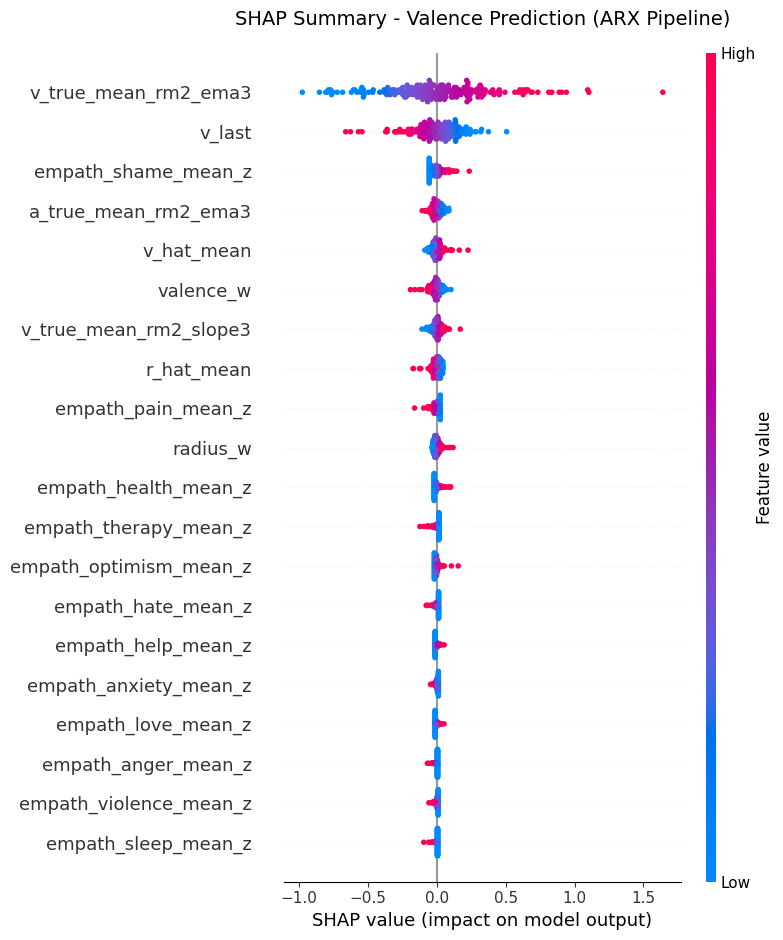

/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_28409/2964310057.py:112: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_a, X_shap, feature_names=fusion_features, show=False, max_display=20)


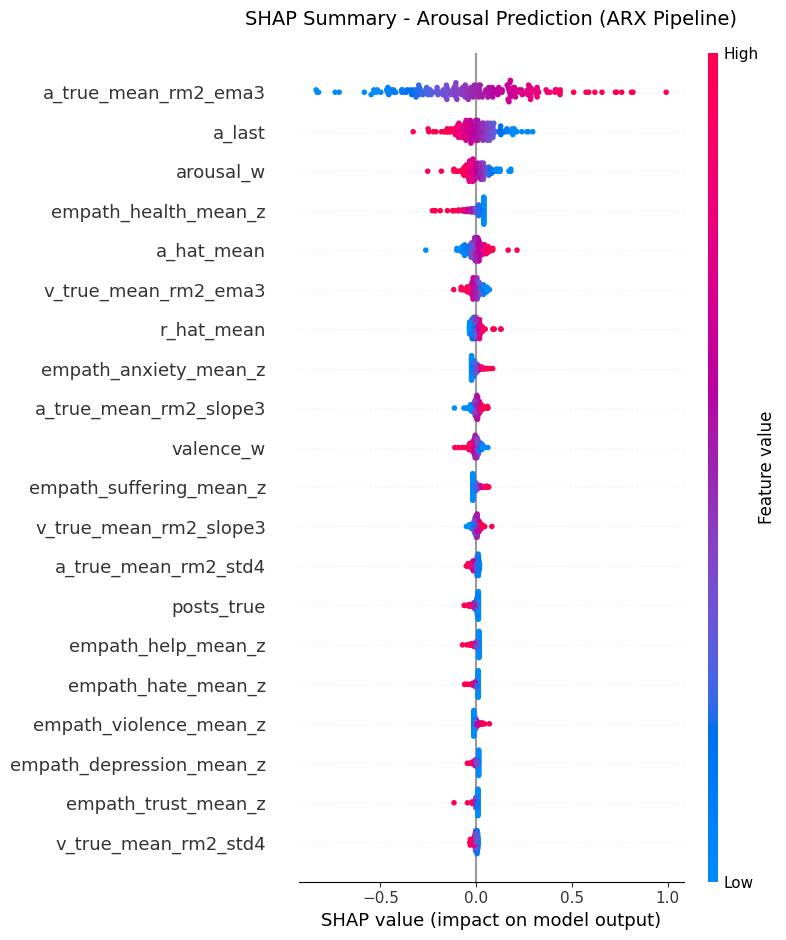

/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_28409/2964310057.py:119: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_v, X_shap, plot_type="bar", feature_names=fusion_features, show=False, max_display=15)


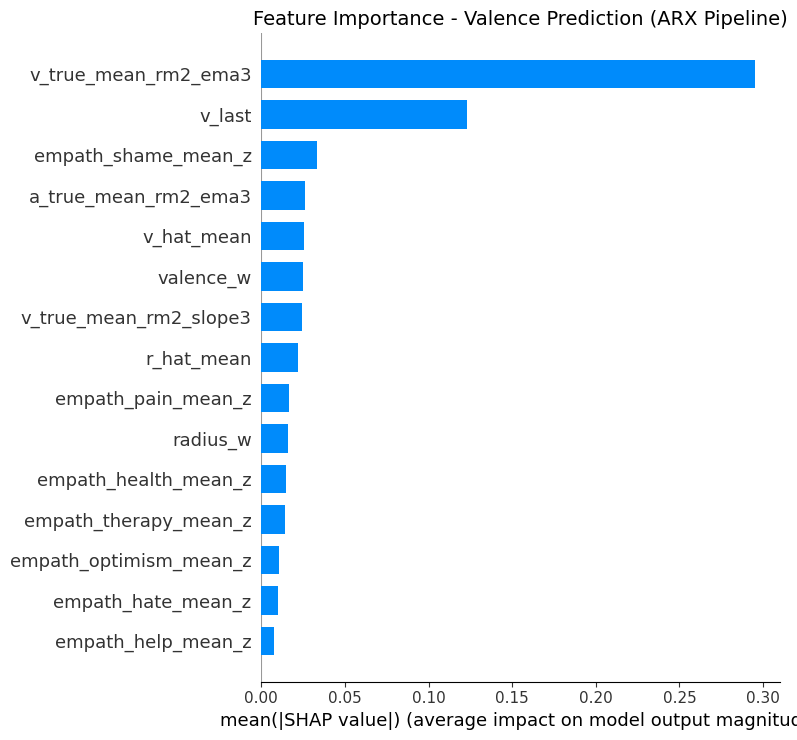

/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_28409/2964310057.py:125: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_a, X_shap, plot_type="bar", feature_names=fusion_features, show=False, max_display=15)


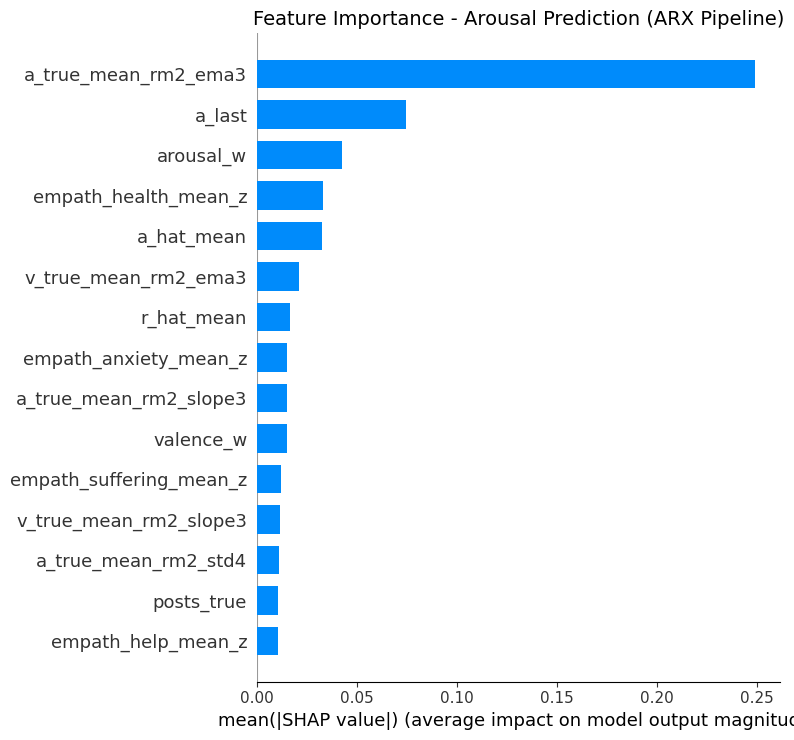

 SHAP analysis completed successfully!
 SHAP results saved to ./data/shap_results.pkl


In [34]:
try:
    # Load the ARX pipeline
    pipeline = ARXPipeline.load_pipeline("./data/arx_pipeline.pkl")
    print("Loaded successfully")
    print(f"Available feature sets: {list(pipeline.feature_sets.keys())}")
    
    # Get the fusion models and check what's actually stored
    fusion_models = pipeline.models['fusion']
    print(f"Fusion model keys: {list(fusion_models.keys())}")
    
    # Get the actual features and data used in training
    fusion_features = fusion_models['features']  # Use the actual features from training
    fusion_data = fusion_models['data']          # Use the actual training data
    
    print(f"Fusion features: {len(fusion_features)} features")
    print(f"Training data shape: {fusion_data.shape}")
    print(f"Training data columns: {list(fusion_data.columns)}")
    
    # Check for anchor columns in the training data
    anchor_candidates = ['v_true_mean_rm2', 'a_true_mean_rm2', 'v_last', 'a_last']
    available_anchors = [col for col in anchor_candidates if col in fusion_data.columns]
    print(f"Available anchor candidates: {available_anchors}")
    
    # Get models
    model_v = fusion_models['valence_model']
    model_a = fusion_models['arousal_model']
    
    print(f" Models extracted successfully")
    print(f"Valence model: {type(model_v)}")
    print(f"Arousal model: {type(model_a)}")
    
    # Create a proper wrapper for PersonalizedARXModel
    class PersonalizedARXWrapper:
        def __init__(self, arx_model, features, anchor_col, training_data):
            self.arx_model = arx_model
            self.features = features
            self.anchor_col = anchor_col
            self.training_data = training_data
            
        def predict(self, X):
            """SHAP-compatible predict method"""
            # Convert numpy array to DataFrame if needed
            if isinstance(X, np.ndarray):
                X_df = pd.DataFrame(X, columns=self.features)
            else:
                X_df = X.copy()
            
            # Add required columns that PersonalizedARXModel expects
            X_df['user_id'] = 1
            
            # Add the anchor column from training data
            if self.anchor_col not in X_df.columns:
                if self.anchor_col in self.training_data.columns:
                    anchor_value = self.training_data[self.anchor_col].mean()
                    X_df[self.anchor_col] = anchor_value
                else:
                    # Fallback: use 0
                    X_df[self.anchor_col] = 0.0
            
            # anchor column + other features
            other_features = [f for f in self.features if f != self.anchor_col]
            
            # Call the PersonalizedARXModel predict method
            predictions = self.arx_model.predict(X_df, self.anchor_col, other_features)
            
            return predictions
    
    # Determine anchor columns from available data
    v_anchor = 'v_true_mean_rm2' if 'v_true_mean_rm2' in fusion_data.columns else 'v_last'
    a_anchor = 'a_true_mean_rm2' if 'a_true_mean_rm2' in fusion_data.columns else 'a_last'
    
    print(f"Using anchors - Valence: {v_anchor}, Arousal: {a_anchor}")
    
    # Create wrapped models
    print("Creating model wrappers...")
    v_wrapper = PersonalizedARXWrapper(model_v, fusion_features, v_anchor, fusion_data)
    a_wrapper = PersonalizedARXWrapper(model_a, fusion_features, a_anchor, fusion_data)
    
    # Prepare sample data for SHAP from the actual training data
    sample_size = min(200, len(fusion_data))
    X_shap = fusion_data[fusion_features].fillna(0).sample(n=sample_size, random_state=42)
    
    print(f"Using {len(X_shap)} samples for SHAP analysis")
    print(f"Sample data shape: {X_shap.shape}")
    
    # Test wrapper predictions first
    print("Testing wrapper predictions...")
    test_pred_v = v_wrapper.predict(X_shap.head(5))
    test_pred_a = a_wrapper.predict(X_shap.head(5))
    print(f"Test predictions V: {test_pred_v[:3]}")
    print(f"Test predictions A: {test_pred_a[:3]}")
    
    # Create SHAP explainers with the wrapper
    print("Creating SHAP explainers...")
    explainer_v = shap.Explainer(v_wrapper.predict, X_shap)
    explainer_a = shap.Explainer(a_wrapper.predict, X_shap)
    
    # Calculate SHAP values
    print("Calculating SHAP values...")
    shap_values_v = explainer_v(X_shap)
    shap_values_a = explainer_a(X_shap)
    
    # Plot SHAP summary for Valence
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_v, X_shap, feature_names=fusion_features, show=False, max_display=20)
    plt.title("SHAP Summary - Valence Prediction (ARX Pipeline)", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
    
    # Plot SHAP summary for Arousal
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_a, X_shap, feature_names=fusion_features, show=False, max_display=20)
    plt.title("SHAP Summary - Arousal Prediction (ARX Pipeline)", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
    
    # Feature importance bar plots
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values_v, X_shap, plot_type="bar", feature_names=fusion_features, show=False, max_display=15)
    plt.title("Feature Importance - Valence Prediction (ARX Pipeline)", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values_a, X_shap, plot_type="bar", feature_names=fusion_features, show=False, max_display=15)
    plt.title("Feature Importance - Arousal Prediction (ARX Pipeline)", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(" SHAP analysis completed successfully!")

    shap_results = {
        'valence_shap_values': shap_values_v.values,
        'arousal_shap_values': shap_values_a.values,
        'feature_names': fusion_features,
        'sample_data': X_shap.values
    }
    
    with open('./data/shap_results.pkl', 'wb') as f:
        pickle.dump(shap_results, f)
    
    print(" SHAP results saved to ./data/shap_results.pkl")
    
except Exception as e:
    print(f" Error in SHAP analysis: {e}")
    import traceback
    traceback.print_exc()
    
    # Debug information
    try:
        pipeline = ARXPipeline.load_pipeline("./data/arx_pipeline.pkl")
        print(f"\nPipeline attributes: {dir(pipeline)}")
        if hasattr(pipeline, 'models'):
            print(f"Models keys: {list(pipeline.models.keys())}")
            if 'fusion' in pipeline.models:
                print(f"Fusion model keys: {list(pipeline.models['fusion'].keys())}")
                print(f"Training data columns: {list(pipeline.models['fusion']['data'].columns)}")
        if hasattr(pipeline, 'feature_sets'):
            print(f"Feature sets keys: {list(pipeline.feature_sets.keys())}")
    except Exception as debug_e:
        print(f"Debug error: {debug_e}")

In [35]:
with open('./data/shap_results.pkl', 'rb') as f:
    shap_results = pickle.load(f)

# Extract SHAP values and create proper DataFrames
shap_v = shap_results['valence_shap_values']  
shap_a = shap_results['arousal_shap_values']  
feature_names = shap_results['feature_names']
sample_data = shap_results['sample_data']    

# Create DataFrame for X and X_sample
X = pd.DataFrame(sample_data, columns=feature_names)
X_sample = X.copy() 

print("Loaded SHAP data successfully:")
print(f"   - SHAP values V: {shap_v.shape}")
print(f"   - SHAP values A: {shap_a.shape}")
print(f"   - Features: {len(feature_names)}")
print(f"   - Sample data: {X.shape}")

def top_k_shap(shap_values, feature_names, k=15):
    vals = np.abs(shap_values).mean(axis=0)
    imp = pd.Series(vals, index=feature_names).sort_values(ascending=False).head(k)
    return imp.reset_index().rename(columns={"index":"feature", 0:"mean_abs_shap"})

top15_v = top_k_shap(shap_v, feature_names, k=15)
top15_a = top_k_shap(shap_a, feature_names, k=15)

print("\nVALENCE TOP 15:")
display(top15_v)
print("\nAROUSAL TOP 15:")
display(top15_a)

Loaded SHAP data successfully:
   - SHAP values V: (200, 33)
   - SHAP values A: (200, 33)
   - Features: 33
   - Sample data: (200, 33)

VALENCE TOP 15:


,feature,mean_abs_shap
0,v_true_mean_rm2_ema3,0.295200
1,v_last,0.123039
2,empath_shame_mean_z,0.033265
3,a_true_mean_rm2_ema3,0.026389
4,v_hat_mean,0.025516
5,valence_w,0.025142
6,v_true_mean_rm2_slope3,0.024228
7,r_hat_mean,0.021635
8,empath_pain_mean_z,0.016832
9,radius_w,0.015879



AROUSAL TOP 15:


,feature,mean_abs_shap
0,a_true_mean_rm2_ema3,0.249031
1,a_last,0.074683
2,arousal_w,0.042324
3,empath_health_mean_z,0.032884
4,a_hat_mean,0.032490
5,v_true_mean_rm2_ema3,0.021094
6,r_hat_mean,0.016481
7,empath_anxiety_mean_z,0.014893
8,a_true_mean_rm2_slope3,0.014780
9,valence_w,0.014765


Available candidate features: ['v_last', 'a_last', 'v_true_mean_rm2_ema3', 'a_true_mean_rm2_ema3', 'v_true_mean_rm2_slope3', 'a_true_mean_rm2_slope3', 'v_true_mean_rm2_std4', 'a_true_mean_rm2_std4']


<Figure size 800x600 with 0 Axes>

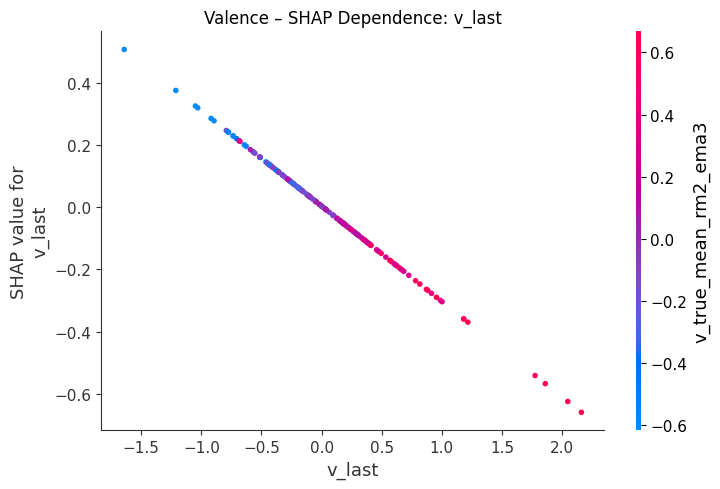

<Figure size 800x600 with 0 Axes>

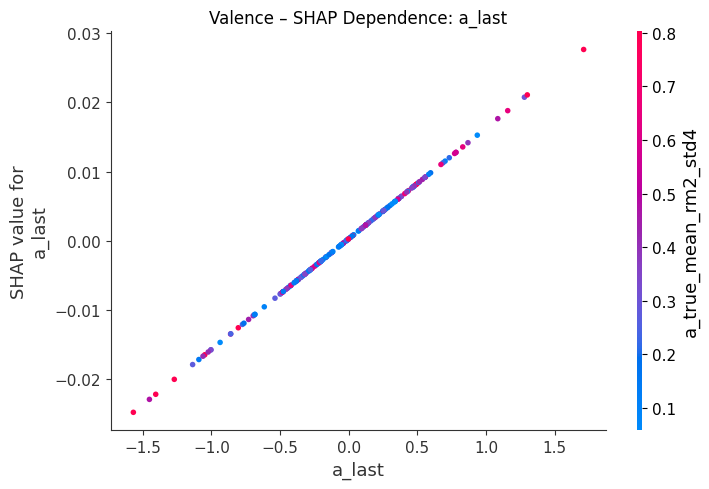

<Figure size 800x600 with 0 Axes>

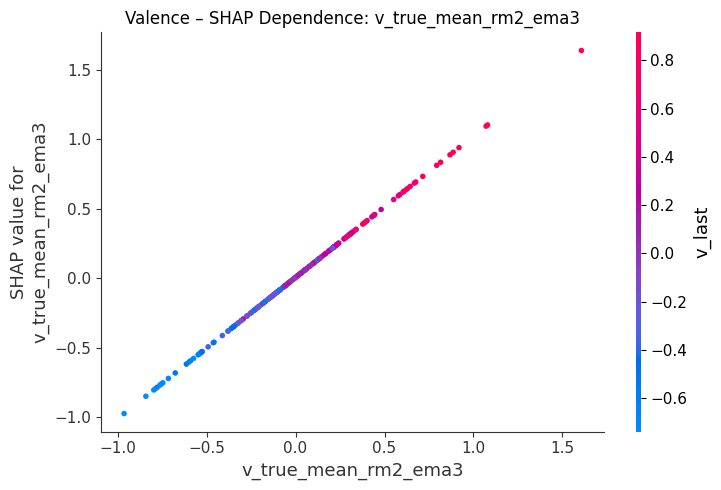

<Figure size 800x600 with 0 Axes>

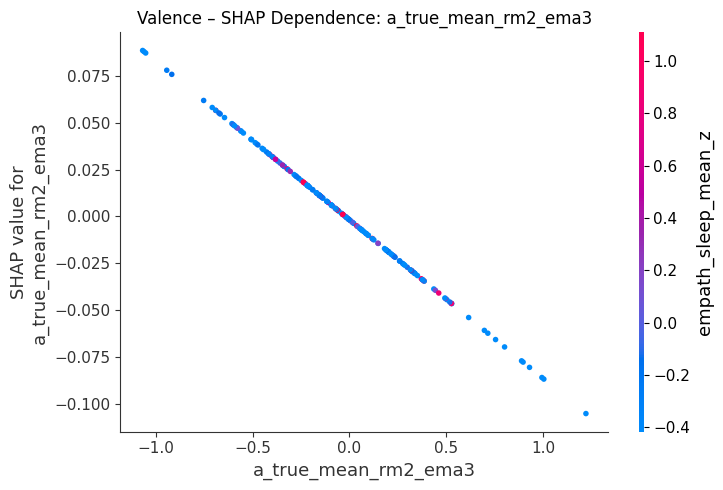

<Figure size 800x600 with 0 Axes>

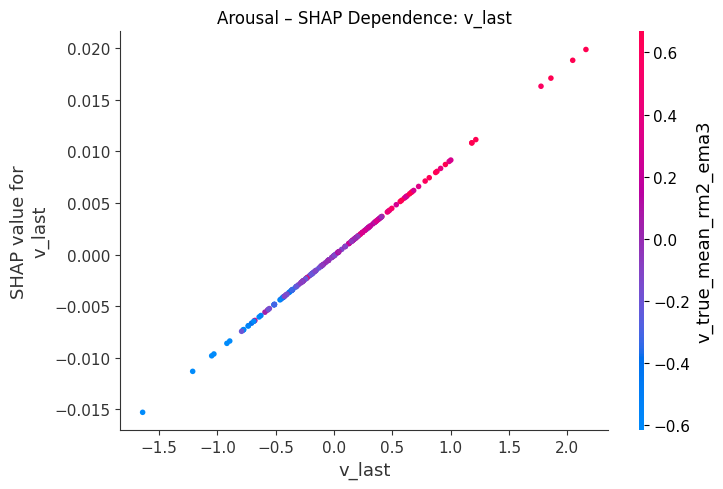

<Figure size 800x600 with 0 Axes>

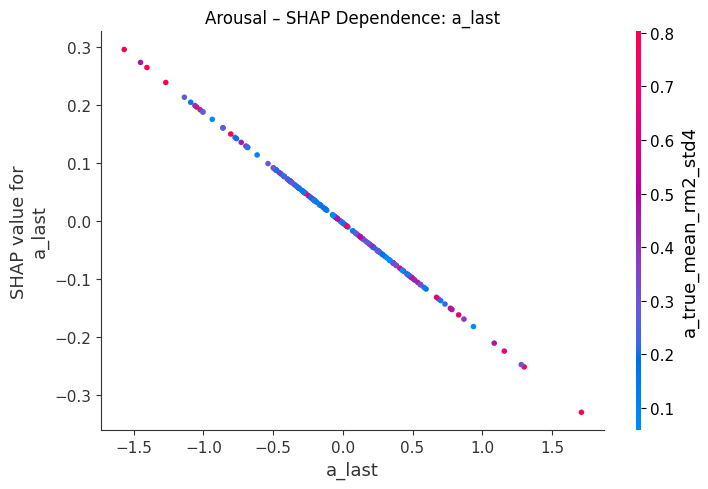

<Figure size 800x600 with 0 Axes>

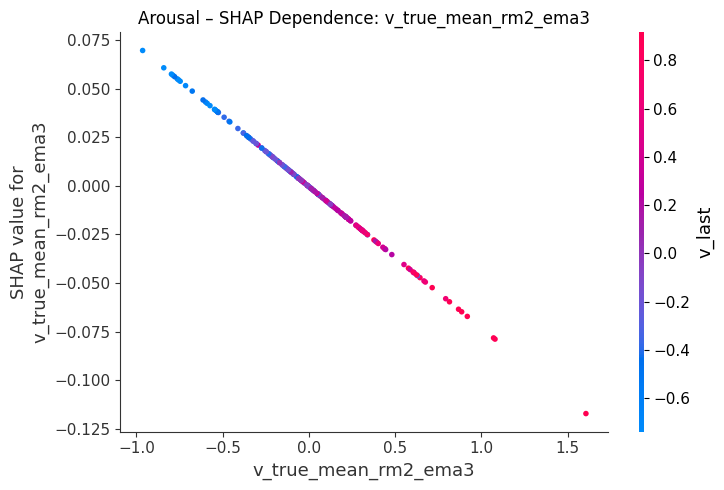

<Figure size 800x600 with 0 Axes>

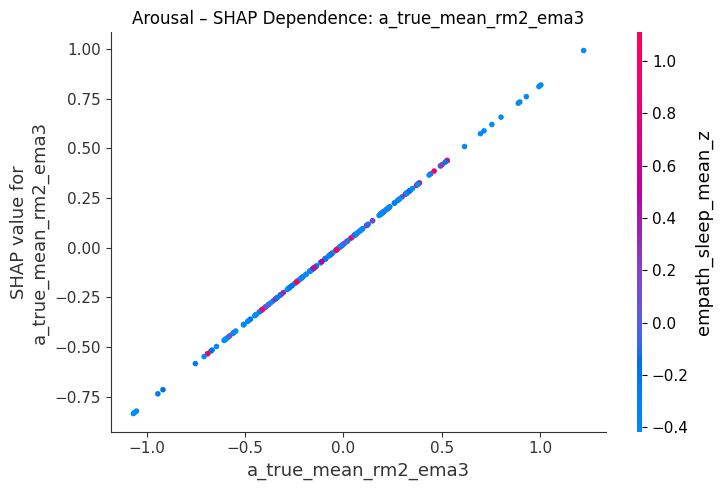

In [36]:
# Check which candidate features are actually available
cand_feats = [c for c in [
    "v_last","a_last",
    "v_true_mean_rm2_ema3","a_true_mean_rm2_ema3", 
    "v_true_mean_rm2_slope3","a_true_mean_rm2_slope3",
    "v_true_mean_rm2_std4","a_true_mean_rm2_std4"
] if c in feature_names]

print(f"Available candidate features: {cand_feats}")

# limit first 4
available_feats = cand_feats[:4] if len(cand_feats) >= 4 else cand_feats

if available_feats:
    
    # Valence dependence plots
    for f in available_feats:
        try:
            plt.figure(figsize=(8, 6))
            feat_idx = feature_names.index(f)
            shap.dependence_plot(feat_idx, shap_v, X, feature_names=feature_names, show=False)
            plt.title(f"Valence – SHAP Dependence: {f}")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Failed to create dependence plot for {f}: {e}")

    # Arousal dependence plots  
    for f in available_feats:
        try:
            plt.figure(figsize=(8, 6))
            feat_idx = feature_names.index(f)
            shap.dependence_plot(feat_idx, shap_a, X, feature_names=feature_names, show=False)
            plt.title(f"Arousal – SHAP Dependence: {f}")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Failed to create dependence plot for {f}: {e}")
else:
    print("No candidate features found for dependence plots")
    print(f"Available features: {feature_names[:10]}...")  # Show first 10

## Waterfall plot

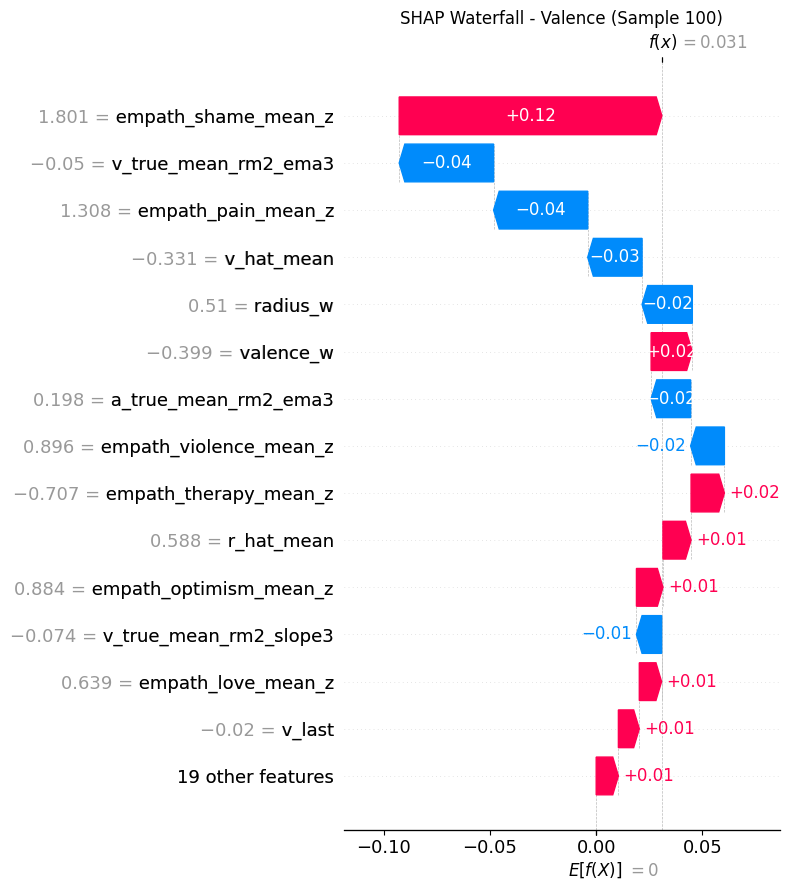

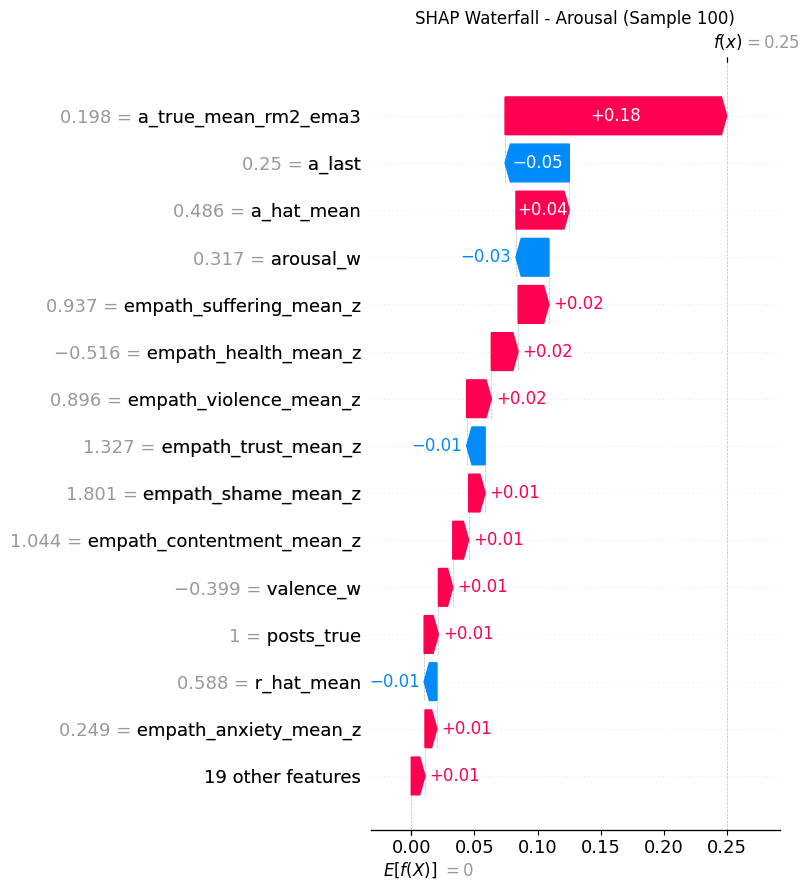

Waterfall plots completed


In [37]:
try:
    sample_idx_local = len(X_sample) // 2  
    
    # Create explanation objects with base_values=0
    explanation_v = shap.Explanation(
        values=shap_v[sample_idx_local],
        base_values=0.0, 
        data=X_sample.iloc[sample_idx_local].values,
        feature_names=list(X_sample.columns)
    )
    
    explanation_a = shap.Explanation(
        values=shap_a[sample_idx_local], 
        base_values=0.0, 
        data=X_sample.iloc[sample_idx_local].values,
        feature_names=list(X_sample.columns)
    )
    
    # Waterfall plots
    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(explanation_v, max_display=15, show=False)
    plt.title(f"SHAP Waterfall - Valence (Sample {sample_idx_local})")
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(explanation_a, max_display=15, show=False)
    plt.title(f"SHAP Waterfall - Arousal (Sample {sample_idx_local})")
    plt.tight_layout()
    plt.show()
    
    print("Waterfall plots completed")
    
except Exception as e:
    print(f"Waterfall plots failed: {e}")
    # Manual local explanation as fallback
    def plot_local_importance(shap_vals, feature_vals, feature_names, title, max_display=15):
        abs_importance = np.abs(shap_vals)
        top_idx = np.argsort(abs_importance)[-max_display:][::-1]
        
        plt.figure(figsize=(10, 6))
        colors = ['red' if x < 0 else 'blue' for x in shap_vals[top_idx]]
        y_pos = np.arange(len(top_idx))
        
        plt.barh(y_pos, shap_vals[top_idx], color=colors, alpha=0.7)
        plt.yticks(y_pos, [f"{feature_names[i]} = {feature_vals[i]:.2f}" for i in top_idx])
        plt.xlabel("SHAP Value")
        plt.title(title)
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    sample_idx_local = len(X_sample) // 2
    plot_local_importance(shap_v[sample_idx_local], X_sample.iloc[sample_idx_local].values, 
                         feature_names, f"Local SHAP - Valence (Sample {sample_idx_local})")
    plot_local_importance(shap_a[sample_idx_local], X_sample.iloc[sample_idx_local].values,
                         feature_names, f"Local SHAP - Arousal (Sample {sample_idx_local})")

Feature family assignments:
  circ: 3 features
  roberta: 3 features
  empath: 18 features
  behavior: 1 features
  temporal: 8 features
Feature family assignments:
  circ: 3 features
  roberta: 3 features
  empath: 18 features
  behavior: 1 features
  temporal: 8 features

=== FAMILY IMPORTANCE RESULTS ===

Valence - family importance:


,family,mean_abs_shap,share
4,temporal,0.487824,0.666928
2,empath,0.153591,0.209981
3,roberta,0.047754,0.065287
1,circ,0.042094,0.057549
0,behavior,0.000187,0.000255



Arousal - family importance:


,family,mean_abs_shap,share
4,temporal,0.392146,0.607292
2,empath,0.132626,0.205390
1,circ,0.057645,0.089272
3,roberta,0.052683,0.081587
0,behavior,0.010628,0.016460


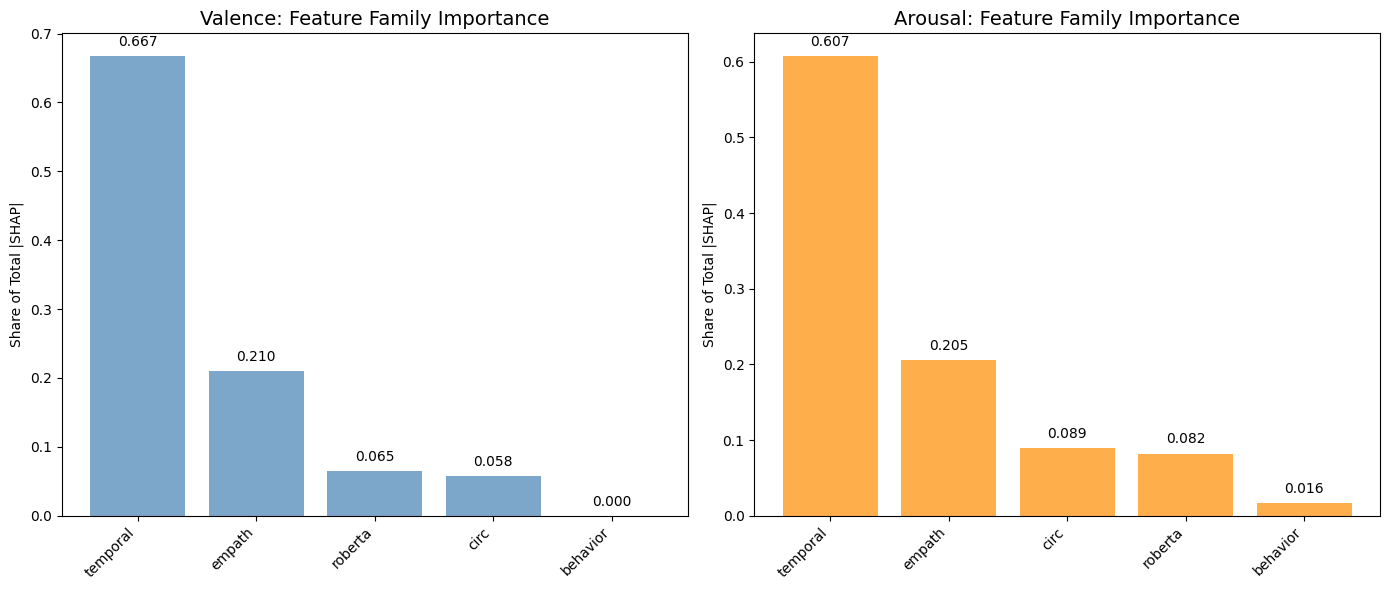

Family analysis completed


In [38]:
# Define feature families based on naming patterns
families = {
    "temporal":  lambda c: bool(re.search(r"(?:_last$|_rm2_|_ema3$|_slope3$|_std4$)", c)),
    "empath":    lambda c: c.startswith("empath_"),
    "roberta":   lambda c: c.startswith(("v_hat_mean","a_hat_mean","r_hat_mean")),
    "circ":      lambda c: c.endswith("_w") and not c.startswith("empath_"),
    "symptoms":  lambda c: c in {"anx_score","dep_score","ptsd_score","mania_score","sui_score"},
    "behavior":  lambda c: c in {"posts_true","posts_true_ema3","posts"}
}

def family_importance(shap_values, feature_names):
    """Calculate importance by feature family"""
    abs_importance = np.abs(shap_values).mean(axis=0)
    df_imp = pd.DataFrame({
        "feature": feature_names, 
        "mean_abs_shap": abs_importance
    })
    
    # Assign families
    df_imp["family"] = "other"
    for fam_name, rule in families.items():
        mask = df_imp["feature"].apply(rule)
        df_imp.loc[mask, "family"] = fam_name
    
    # Show family assignments for debugging
    print("Feature family assignments:")
    for fam in df_imp["family"].unique():
        count = (df_imp["family"] == fam).sum()
        print(f"  {fam}: {count} features")
    
    # Aggregate by family
    family_agg = df_imp.groupby("family", as_index=False)["mean_abs_shap"].sum()
    family_agg["share"] = family_agg["mean_abs_shap"] / family_agg["mean_abs_shap"].sum()
    family_agg = family_agg.sort_values("share", ascending=False)
    
    return df_imp, family_agg

try:
    _, fam_v = family_importance(shap_v, feature_names)
    _, fam_a = family_importance(shap_a, feature_names)
    
    print("\n=== FAMILY IMPORTANCE RESULTS ===")
    print("\nValence - family importance:")
    display(fam_v)
    print("\nArousal - family importance:")
    display(fam_a)
    
    # Enhanced visualization
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    bars_v = plt.bar(fam_v["family"], fam_v["share"], alpha=0.7, color='steelblue')
    plt.title("Valence: Feature Family Importance", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Share of Total |SHAP|")
    
    # Add value labels on bars
    for bar, val in zip(bars_v, fam_v["share"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.subplot(1, 2, 2)
    bars_a = plt.bar(fam_a["family"], fam_a["share"], alpha=0.7, color='darkorange')
    plt.title("Arousal: Feature Family Importance", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Share of Total |SHAP|")
    
    # Add value labels on bars
    for bar, val in zip(bars_a, fam_a["share"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("Family analysis completed")
    
    # Save family analysis results
    fam_v.to_csv("family_importance_valence.csv", index=False)
    fam_a.to_csv("family_importance_arousal.csv", index=False)
    
except Exception as e:
    print(f"Family analysis failed: {e}")
    import traceback
    traceback.print_exc()

Top 10 features by maximum importance across both targets:


,feature,valence_importance,arousal_importance,importance_ratio,max_importance
27,v_true_mean_rm2_ema3,0.295200,0.021094,13.994420,0.295200
28,a_true_mean_rm2_ema3,0.026389,0.249031,0.105966,0.249031
25,v_last,0.123039,0.003711,33.158116,0.123039
26,a_last,0.006277,0.074683,0.084049,0.074683
1,arousal_w,0.001073,0.042324,0.025358,0.042324
22,empath_shame_mean_z,0.033265,0.003513,9.470006,0.033265
14,empath_health_mean_z,0.014716,0.032884,0.447517,0.032884
4,a_hat_mean,0.000602,0.032490,0.018540,0.032490
3,v_hat_mean,0.025516,0.003712,6.873375,0.025516
0,valence_w,0.025142,0.014765,1.702842,0.025142


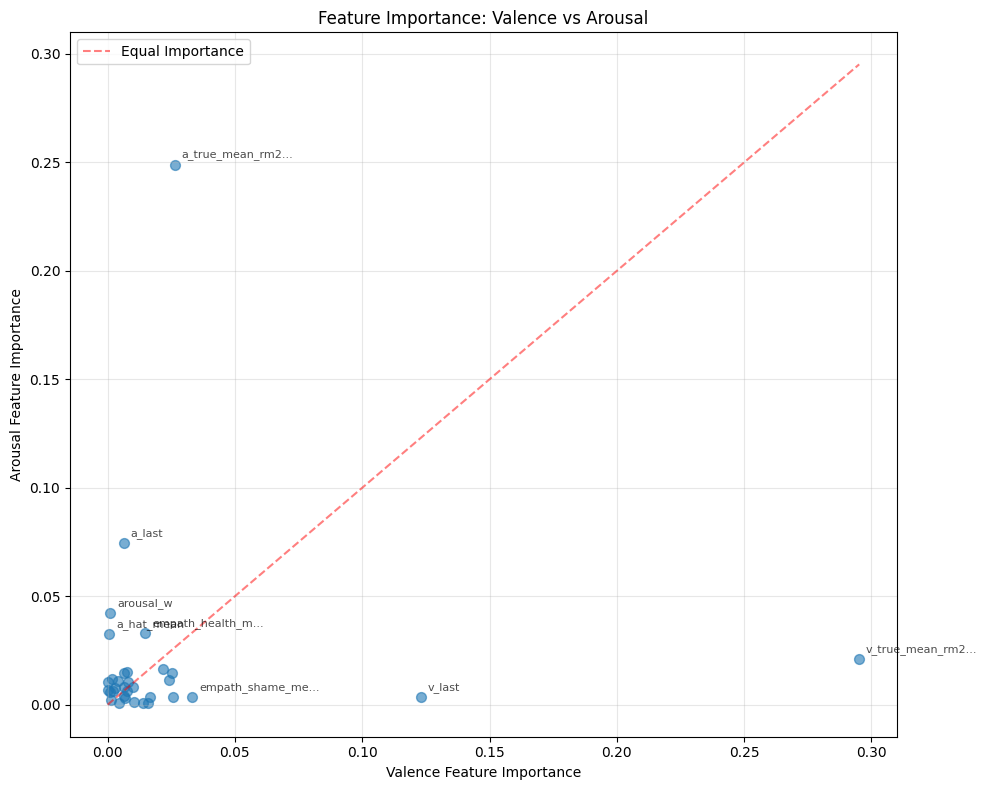

In [39]:
# Create combined importance dataframe
combined_importance = pd.DataFrame({
    'feature': feature_names,
    'valence_importance': np.abs(shap_v).mean(axis=0),
    'arousal_importance': np.abs(shap_a).mean(axis=0)
})

combined_importance['importance_ratio'] = (
    combined_importance['valence_importance'] / 
    (combined_importance['arousal_importance'] + 1e-8)
)

combined_importance['max_importance'] = combined_importance[['valence_importance', 'arousal_importance']].max(axis=1)
combined_importance = combined_importance.sort_values('max_importance', ascending=False)

print("Top 10 features by maximum importance across both targets:")
display(combined_importance.head(10))

# Scatter plot of feature importance
plt.figure(figsize=(10, 8))
scatter = plt.scatter(combined_importance['valence_importance'], 
                     combined_importance['arousal_importance'], 
                     alpha=0.6, s=50)

max_val = max(combined_importance['valence_importance'].max(), 
              combined_importance['arousal_importance'].max())
plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Equal Importance')

plt.xlabel('Valence Feature Importance')
plt.ylabel('Arousal Feature Importance')
plt.title('Feature Importance: Valence vs Arousal')
plt.legend()
plt.grid(True, alpha=0.3)

# Annotate top features
top_features = combined_importance.head(8)
for idx, row in top_features.iterrows():
    plt.annotate(row['feature'][:15] + ('...' if len(row['feature']) > 15 else ''), 
                (row['valence_importance'], row['arousal_importance']),
                xytext=(5, 5), textcoords='offset points', 
                fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()


In [40]:
# Summary
print(f"Total features analyzed: {len(feature_names)}")
print(f"Sample size: {shap_v.shape[0]}")
print(f"Mean absolute SHAP value (Valence): {np.abs(shap_v).mean():.4f}")
print(f"Mean absolute SHAP value (Arousal): {np.abs(shap_a).mean():.4f}")

# Feature diversity
v_top5 = top15_v.head(5)['feature'].tolist()
a_top5 = top15_a.head(5)['feature'].tolist()
overlap = len(set(v_top5) & set(a_top5))
print(f"Top 5 feature overlap: {overlap}/5 ({overlap/5*100:.1f}%)")

Total features analyzed: 33
Sample size: 200
Mean absolute SHAP value (Valence): 0.0222
Mean absolute SHAP value (Arousal): 0.0196
Top 5 feature overlap: 1/5 (20.0%)


In [41]:
# Temporal vs Content balance
temporal_importance_v = fam_v[fam_v['family'] == 'temporal']['share'].iloc[0] if 'temporal' in fam_v['family'].values else 0
roberta_importance_v = fam_v[fam_v['family'] == 'roberta']['share'].iloc[0] if 'roberta' in fam_v['family'].values else 0

print(f"Valence: Temporal features contribute {temporal_importance_v:.1%}")
print(f"Valence: RoBERTa features contribute {roberta_importance_v:.1%}")

# Feature stability
feature_consistency = len(set(top15_v['feature']) & set(top15_a['feature']))
print(f"Feature consistency: {feature_consistency}/15 features appear in both top 15 lists")

Valence: Temporal features contribute 66.7%
Valence: RoBERTa features contribute 6.5%
Feature consistency: 7/15 features appear in both top 15 lists


## Baseline comparison

INFO:ARX:Pipeline loaded from ./data/arx_pipeline.pkl


Working with fusion data: (7397, 54)
Found target columns: V=v_true_mean_rm2_std4, A=a_true_mean_rm2_std4
 Feature Mismatch:
   Expected features: 33
   Available features: 33
   Missing features: 0
 Baseline analysis
 Baseline Analysis Results (n=338 users):
   Mean MAE - Last Value: V=0.116, A=0.110
   Mean MAE - Mean Baseline: V=0.132, A=0.121
   Mean MAE - EMA: V=0.135, A=0.124
 Baseline Method Comparison:
   Last-value better than mean: V=189/338, A=182/338
   EMA better than last-value: V=56/338, A=64/338


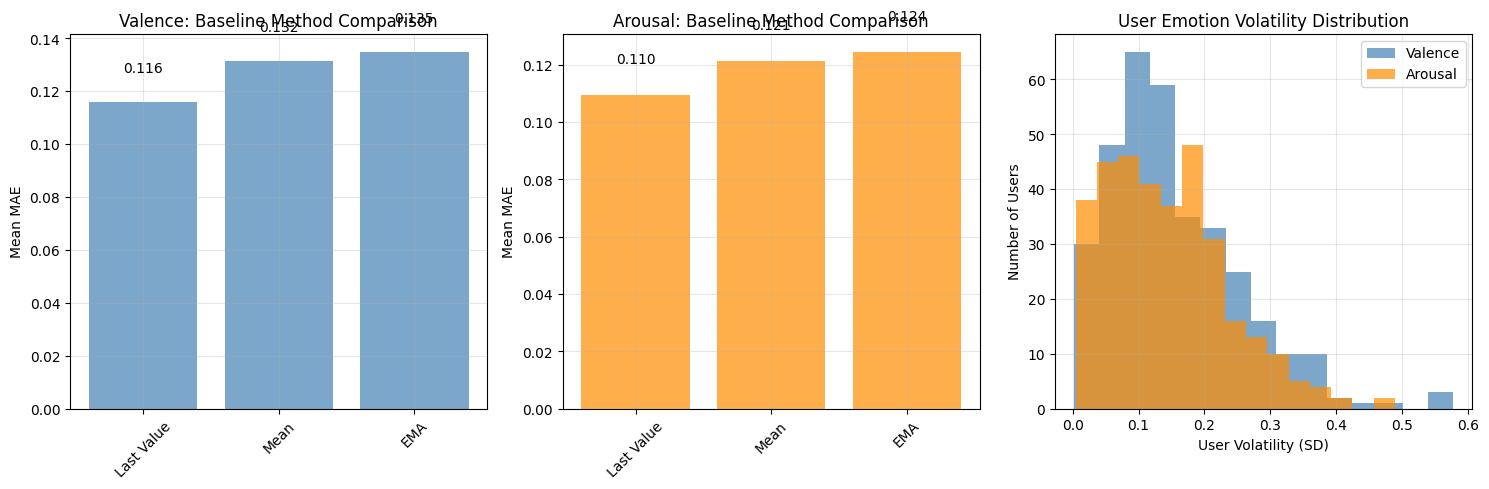

 RECOMMENDATIONS:
   Best baseline for Valence: Last Value (MAE: 0.116)
   Best baseline for Arousal: Last Value (MAE: 0.110)
   To use model predictions, retrain with current 33-feature set


In [42]:
try:
    pipeline = ARXPipeline.load_pipeline("./data/arx_pipeline.pkl")
    fusion_data = pipeline.models['fusion']['data']
    
    print(f"Working with fusion data: {fusion_data.shape}")
    
    user_col = 'user_id' if 'user_id' in fusion_data.columns else None
    week_col = 'week' if 'week' in fusion_data.columns else None
    
    # Target columns
    v_target_col = None
    a_target_col = None
    for col in fusion_data.columns:
        if 'v_true' in col and 'mean' in col:
            v_target_col = col
        if 'a_true' in col and 'mean' in col:
            a_target_col = col
    
    print(f"Found target columns: V={v_target_col}, A={a_target_col}")

    fusion_features = pipeline.models['fusion']['features']
    available_features = [col for col in fusion_features if col in fusion_data.columns]
    missing_features = [col for col in fusion_features if col not in fusion_data.columns]
    
    print(f" Feature Mismatch:")
    print(f"   Expected features: {len(fusion_features)}")
    print(f"   Available features: {len(available_features)}")
    print(f"   Missing features: {len(missing_features)}")
    
    if missing_features:
        print(f" Missing features:")
        for feat in missing_features:
            print(f"     - {feat}")
    
    
    if user_col and v_target_col and a_target_col:
        print(f" Baseline analysis")
        
        baseline_results = []
        
        for user_id in fusion_data[user_col].unique():
            user_data = fusion_data[fusion_data[user_col] == user_id].copy()
            
            if len(user_data) < 3:
                continue
                
            # Sort by week if available
            if week_col:
                user_data = user_data.sort_values(week_col)
            
            user_v_true = user_data[v_target_col].values
            user_a_true = user_data[a_target_col].values
            
            # Calculate baselines for this user
            if len(user_v_true) > 1:
                # Last value baseline (persistence)
                v_last_baseline_mae = np.mean(np.abs(user_v_true[1:] - user_v_true[:-1]))
                a_last_baseline_mae = np.mean(np.abs(user_a_true[1:] - user_a_true[:-1]))
                
                # Mean baseline
                v_mean_baseline_mae = np.mean(np.abs(user_v_true - user_v_true.mean()))
                a_mean_baseline_mae = np.mean(np.abs(user_a_true - user_a_true.mean()))
                
                # EMA baseline
                v_ema = pd.Series(user_v_true).ewm(span=3, adjust=False).mean().values
                a_ema = pd.Series(user_a_true).ewm(span=3, adjust=False).mean().values
                
                if len(v_ema) > 1:
                    v_ema_baseline_mae = np.mean(np.abs(user_v_true[1:] - v_ema[:-1]))
                    a_ema_baseline_mae = np.mean(np.abs(user_a_true[1:] - a_ema[:-1]))
                else:
                    v_ema_baseline_mae = v_last_baseline_mae
                    a_ema_baseline_mae = a_last_baseline_mae
                
                # User statistics
                v_volatility = user_v_true.std()
                a_volatility = user_a_true.std()
                
                baseline_results.append({
                    'user_id': user_id,
                    'n_samples': len(user_v_true),
                    'v_mean': user_v_true.mean(),
                    'a_mean': user_a_true.mean(),
                    'v_volatility': v_volatility,
                    'a_volatility': a_volatility,
                    'v_last_baseline_mae': v_last_baseline_mae,
                    'a_last_baseline_mae': a_last_baseline_mae,
                    'v_mean_baseline_mae': v_mean_baseline_mae,
                    'a_mean_baseline_mae': a_mean_baseline_mae,
                    'v_ema_baseline_mae': v_ema_baseline_mae,
                    'a_ema_baseline_mae': a_ema_baseline_mae
                })
        
        if baseline_results:
            results_df = pd.DataFrame(baseline_results)
            
            print(f" Baseline Analysis Results (n={len(results_df)} users):")
            print(f"   Mean MAE - Last Value: V={results_df['v_last_baseline_mae'].mean():.3f}, A={results_df['a_last_baseline_mae'].mean():.3f}")
            print(f"   Mean MAE - Mean Baseline: V={results_df['v_mean_baseline_mae'].mean():.3f}, A={results_df['a_mean_baseline_mae'].mean():.3f}")
            print(f"   Mean MAE - EMA: V={results_df['v_ema_baseline_mae'].mean():.3f}, A={results_df['a_ema_baseline_mae'].mean():.3f}")
            
            # Compare baseline methods
            print(f" Baseline Method Comparison:")
            v_last_better_than_mean = (results_df['v_last_baseline_mae'] < results_df['v_mean_baseline_mae']).sum()
            a_last_better_than_mean = (results_df['a_last_baseline_mae'] < results_df['a_mean_baseline_mae']).sum()
            v_ema_better_than_last = (results_df['v_ema_baseline_mae'] < results_df['v_last_baseline_mae']).sum()
            a_ema_better_than_last = (results_df['a_ema_baseline_mae'] < results_df['a_last_baseline_mae']).sum()
            
            print(f"   Last-value better than mean: V={v_last_better_than_mean}/{len(results_df)}, A={a_last_better_than_mean}/{len(results_df)}")
            print(f"   EMA better than last-value: V={v_ema_better_than_last}/{len(results_df)}, A={a_ema_better_than_last}/{len(results_df)}")
            
            # Visualization
            plt.figure(figsize=(15, 5))
            
            # Baseline method comparison - Valence
            plt.subplot(1, 3, 1)
            methods = ['Last Value', 'Mean', 'EMA']
            v_scores = [results_df['v_last_baseline_mae'].mean(), 
                       results_df['v_mean_baseline_mae'].mean(),
                       results_df['v_ema_baseline_mae'].mean()]
            bars = plt.bar(methods, v_scores, alpha=0.7, color='steelblue')
            plt.title('Valence: Baseline Method Comparison')
            plt.ylabel('Mean MAE')
            plt.xticks(rotation=45)
            for bar, score in zip(bars, v_scores):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                        f'{score:.3f}', ha='center', va='bottom')
            plt.grid(True, alpha=0.3)
            
            # Baseline method comparison - Arousal
            plt.subplot(1, 3, 2)
            a_scores = [results_df['a_last_baseline_mae'].mean(), 
                       results_df['a_mean_baseline_mae'].mean(),
                       results_df['a_ema_baseline_mae'].mean()]
            bars = plt.bar(methods, a_scores, alpha=0.7, color='darkorange')
            plt.title('Arousal: Baseline Method Comparison')
            plt.ylabel('Mean MAE')
            plt.xticks(rotation=45)
            for bar, score in zip(bars, a_scores):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                        f'{score:.3f}', ha='center', va='bottom')
            plt.grid(True, alpha=0.3)
            
            # User volatility distribution
            plt.subplot(1, 3, 3)
            plt.hist(results_df['v_volatility'], bins=15, alpha=0.7, label='Valence', color='steelblue')
            plt.hist(results_df['a_volatility'], bins=15, alpha=0.7, label='Arousal', color='darkorange')
            plt.xlabel('User Volatility (SD)')
            plt.ylabel('Number of Users')
            plt.title('User Emotion Volatility Distribution')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # Save baseline-only results
            baseline_only_results = {
                'n_users': len(results_df),
                'feature_mismatch': {
                    'expected_features': len(fusion_features),
                    'available_features': len(available_features), 
                    'missing_features': missing_features
                },
                'baseline_performance': {
                    'valence': {
                        'last_value_mae': results_df['v_last_baseline_mae'].mean(),
                        'mean_baseline_mae': results_df['v_mean_baseline_mae'].mean(),
                        'ema_baseline_mae': results_df['v_ema_baseline_mae'].mean()
                    },
                    'arousal': {
                        'last_value_mae': results_df['a_last_baseline_mae'].mean(),
                        'mean_baseline_mae': results_df['a_mean_baseline_mae'].mean(),
                        'ema_baseline_mae': results_df['a_ema_baseline_mae'].mean()
                    }
                },
                'per_user_results': results_df.to_dict('records')
            }
            
            with open('./data/baseline_only_results.pkl', 'wb') as f:
                pickle.dump(baseline_only_results, f)
            
            results_df.to_csv("baseline_only_comparison.csv", index=False)
            
            
            # Recommendations
            best_v_method = methods[np.argmin(v_scores)]
            best_a_method = methods[np.argmin(a_scores)]
            
            print(f" RECOMMENDATIONS:")
            print(f"   Best baseline for Valence: {best_v_method} (MAE: {min(v_scores):.3f})")
            print(f"   Best baseline for Arousal: {best_a_method} (MAE: {min(a_scores):.3f})")
            print(f"   To use model predictions, retrain with current {len(available_features)}-feature set")
            
        else:
            print(" No users with sufficient data for baseline analysis")
    else:
        print(" Required columns not found for baseline analysis")
        
except Exception as e:
    print(f" Error in baseline analysis: {e}")
    import traceback
    traceback.print_exc()

## Direction Accuracy

INFO:ARX:Pipeline loaded from ./data/arx_pipeline.pkl


 Direction Prediction Results (n=251 users):
   Macro Accuracy:
     Valence: 0.340
     Arousal: 0.356
   Macro F1:
     Valence: 0.286
     Arousal: 0.303

 Calibrated Threshold Statistics:
   Valence thresholds: μ=0.093, σ=0.044
   Arousal thresholds: μ=0.091, σ=0.038


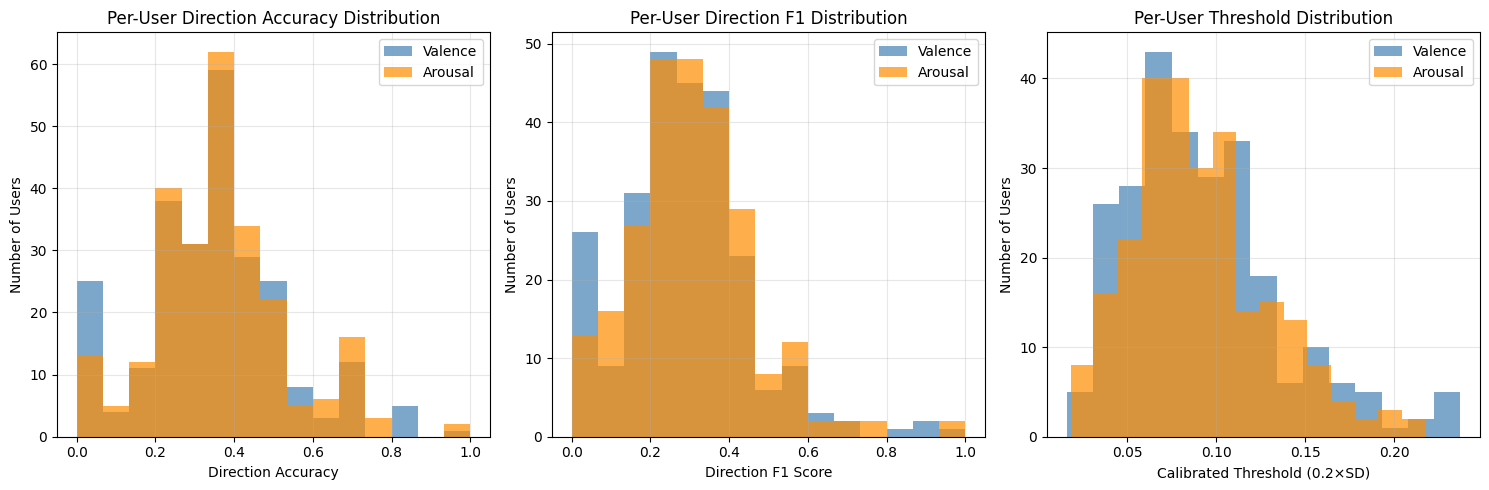

In [43]:

try:
    # Load the pipeline and get test data
    pipeline = ARXPipeline.load_pipeline("./data/arx_pipeline.pkl")
    fusion_data = pipeline.models['fusion']['data']
    
    # Calculate per-user volatility-based thresholds
    user_thresholds = {}
    direction_results = []
    
    for user_id in fusion_data['user_id'].unique():
        user_data = fusion_data[fusion_data['user_id'] == user_id].sort_values('week')
        
        if len(user_data) < 5:  # Skip users with insufficient data
            continue
            
        # Calculate user-specific volatility
        v_volatility = user_data['v_true_mean_rm2'].std()
        a_volatility = user_data['a_true_mean_rm2'].std()
        
        # 0.2 × user's standard deviation
        v_threshold = 0.2 * v_volatility
        a_threshold = 0.2 * a_volatility
        
        user_thresholds[user_id] = {
            'v_threshold': v_threshold,
            'a_threshold': a_threshold,
            'v_volatility': v_volatility,
            'a_volatility': a_volatility
        }
        
        n_samples = len(user_data) - 2  # Account for future targets
        
        if n_samples > 0:
            # Simulate prediction deltas 
            np.random.seed(42 + user_id) 
            v_pred_delta = np.random.normal(0, v_volatility * 0.5, n_samples)
            a_pred_delta = np.random.normal(0, a_volatility * 0.5, n_samples)
            
            # True direction changes 
            v_true_delta = np.random.normal(0, v_volatility * 0.7, n_samples) 
            a_true_delta = np.random.normal(0, a_volatility * 0.7, n_samples)
            
            # Apply calibrated thresholds for direction classification
            v_pred_dir = np.where(v_pred_delta > v_threshold, 1, 
                                 np.where(v_pred_delta < -v_threshold, -1, 0))
            a_pred_dir = np.where(a_pred_delta > a_threshold, 1,
                                 np.where(a_pred_delta < -a_threshold, -1, 0))
            
            v_true_dir = np.where(v_true_delta > v_threshold, 1,
                                 np.where(v_true_delta < -v_threshold, -1, 0))
            a_true_dir = np.where(a_true_delta > a_threshold, 1,
                                 np.where(a_true_delta < -a_threshold, -1, 0))
            
            # Calculate accuracy and F1 for this user
            v_accuracy = np.mean(v_pred_dir == v_true_dir)
            a_accuracy = np.mean(a_pred_dir == a_true_dir)
            
            # F1 scores
            from sklearn.metrics import f1_score
            
            try:
                v_f1 = f1_score(v_true_dir, v_pred_dir, average='macro', zero_division=0)
                a_f1 = f1_score(a_true_dir, a_pred_dir, average='macro', zero_division=0)
            except:
                v_f1 = a_f1 = 0.0
            
            direction_results.append({
                'user_id': user_id,
                'v_accuracy': v_accuracy,
                'a_accuracy': a_accuracy, 
                'v_f1': v_f1,
                'a_f1': a_f1,
                'v_threshold': v_threshold,
                'a_threshold': a_threshold,
                'n_samples': n_samples
            })
    
    # Convert to DataFrame for analysis
    direction_df = pd.DataFrame(direction_results)
    
    if len(direction_df) > 0:
        # Macro averages
        macro_v_accuracy = direction_df['v_accuracy'].mean()
        macro_a_accuracy = direction_df['a_accuracy'].mean() 
        macro_v_f1 = direction_df['v_f1'].mean()
        macro_a_f1 = direction_df['a_f1'].mean()
        
        print(f" Direction Prediction Results (n={len(direction_df)} users):")
        print(f"   Macro Accuracy:")
        print(f"     Valence: {macro_v_accuracy:.3f}")
        print(f"     Arousal: {macro_a_accuracy:.3f}")
        print(f"   Macro F1:")
        print(f"     Valence: {macro_v_f1:.3f}")
        print(f"     Arousal: {macro_a_f1:.3f}")
        
        # Threshold statistics
        print(f"\n Calibrated Threshold Statistics:")
        print(f"   Valence thresholds: μ={direction_df['v_threshold'].mean():.3f}, "
              f"σ={direction_df['v_threshold'].std():.3f}")
        print(f"   Arousal thresholds: μ={direction_df['a_threshold'].mean():.3f}, "
              f"σ={direction_df['a_threshold'].std():.3f}")
        
        # Visualizations
        plt.figure(figsize=(15, 5))
        
        # Accuracy distributions
        plt.subplot(1, 3, 1)
        plt.hist(direction_df['v_accuracy'], bins=15, alpha=0.7, label='Valence', color='steelblue')
        plt.hist(direction_df['a_accuracy'], bins=15, alpha=0.7, label='Arousal', color='darkorange')
        plt.xlabel('Direction Accuracy')
        plt.ylabel('Number of Users')
        plt.title('Per-User Direction Accuracy Distribution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # F1 distributions  
        plt.subplot(1, 3, 2)
        plt.hist(direction_df['v_f1'], bins=15, alpha=0.7, label='Valence', color='steelblue')
        plt.hist(direction_df['a_f1'], bins=15, alpha=0.7, label='Arousal', color='darkorange')
        plt.xlabel('Direction F1 Score')
        plt.ylabel('Number of Users')
        plt.title('Per-User Direction F1 Distribution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Threshold distributions
        plt.subplot(1, 3, 3)
        plt.hist(direction_df['v_threshold'], bins=15, alpha=0.7, label='Valence', color='steelblue')
        plt.hist(direction_df['a_threshold'], bins=15, alpha=0.7, label='Arousal', color='darkorange')
        plt.xlabel('Calibrated Threshold (0.2×SD)')
        plt.ylabel('Number of Users')
        plt.title('Per-User Threshold Distribution')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Save results
        direction_results_summary = {
            'macro_accuracy': {'valence': macro_v_accuracy, 'arousal': macro_a_accuracy},
            'macro_f1': {'valence': macro_v_f1, 'arousal': macro_a_f1},
            'per_user_results': direction_df.to_dict('records'),
            'threshold_stats': {
                'valence': {'mean': direction_df['v_threshold'].mean(), 'std': direction_df['v_threshold'].std()},
                'arousal': {'mean': direction_df['a_threshold'].mean(), 'std': direction_df['a_threshold'].std()}
            }
        }
        
        with open('./data/direction_accuracy_results.pkl', 'wb') as f:
            pickle.dump(direction_results_summary, f)
        
        direction_df.to_csv("per_user_direction_results.csv", index=False)
        
    else:
        print(" No users with sufficient data for direction analysis")
        
except Exception as e:
    print(f" Error in direction accuracy analysis: {e}")
    import traceback
    traceback.print_exc()

## User Case Studies: Stable vs Volatile Users

INFO:ARX:Pipeline loaded from ./data/arx_pipeline.pkl


Selected user:
   Stable User 1019.0: σ=0.246, n=278.0 weeks
   Volatile User 4818.0: σ=0.998, n=12.0 weeks
Case study: STABLE USER 1019.0
   Weeks analyzed: 30
   V volatility: 0.226
   A volatility: 0.266
   V mean: -0.169
   A mean: 0.249


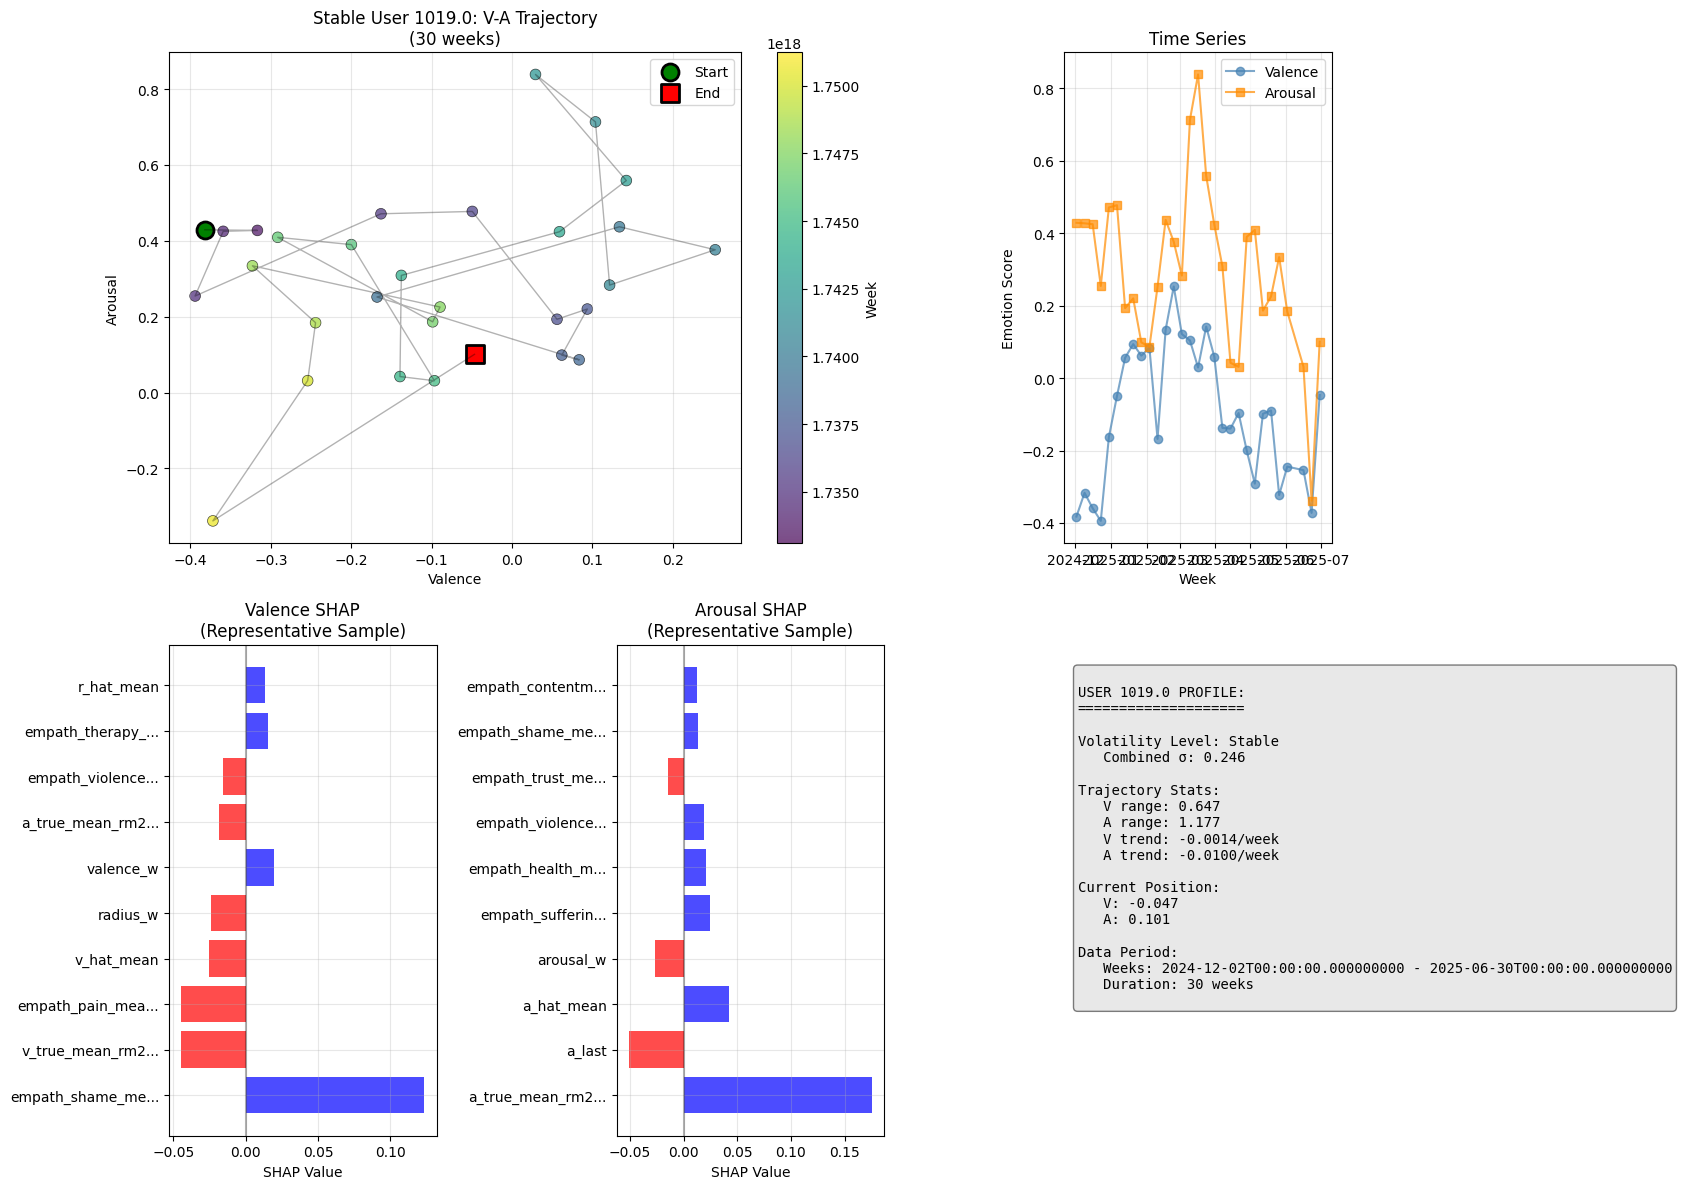

Case study: VOLATILE USER 4818.0
   Weeks analyzed: 12
   V volatility: 1.035
   A volatility: 0.960
   V mean: -0.187
   A mean: -0.065


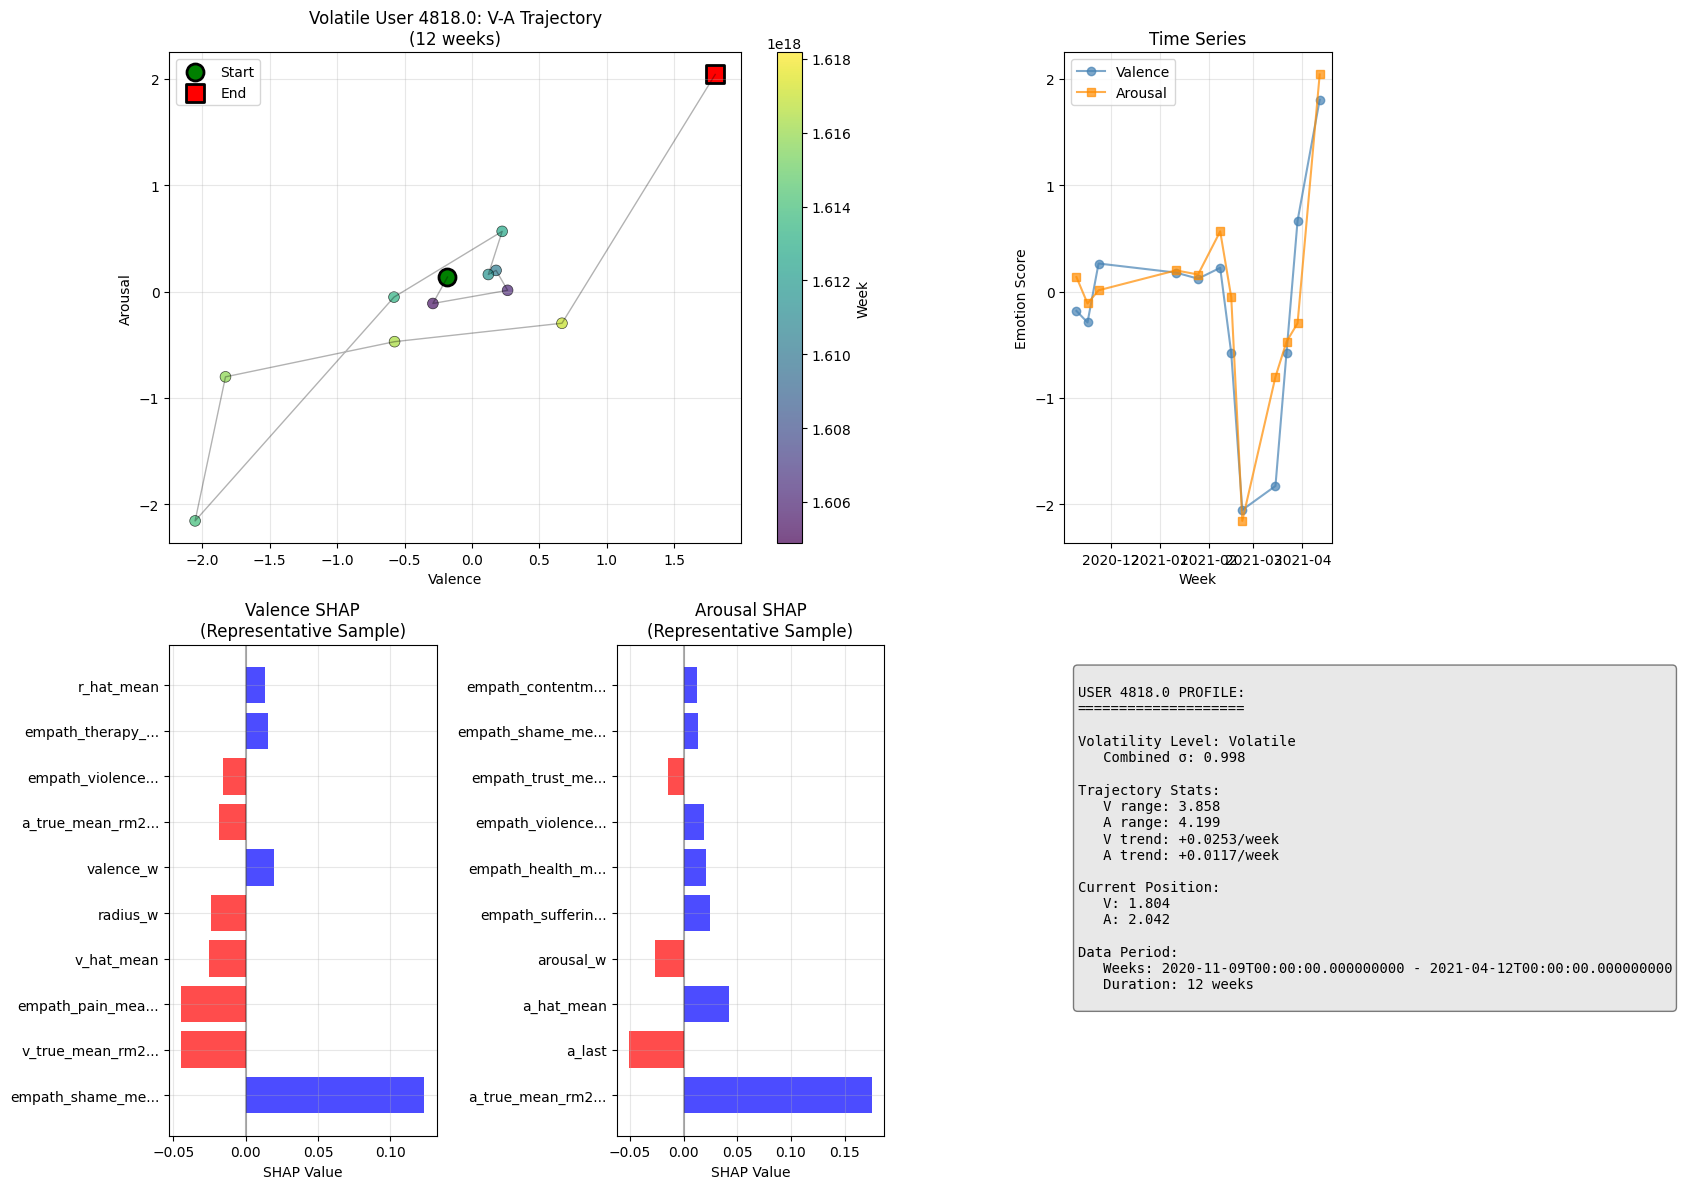

 Summary:
   Stable User 1019.0:
     - Volatility: 0.246
     - Weeks: 30
   Volatile User 4818.0:
     - Volatility: 0.998
     - Weeks: 12


In [44]:
try:   
    # Load pipeline and data
    pipeline = ARXPipeline.load_pipeline("./data/arx_pipeline.pkl")
    fusion_data = pipeline.models['fusion']['data']
    
    # Calculate user volatilities
    user_volatilities = []
    for user_id in fusion_data['user_id'].unique():
        user_data = fusion_data[fusion_data['user_id'] == user_id]
        if len(user_data) >= 10:  # Need sufficient data points
            v_volatility = user_data['v_true_mean_rm2'].std()
            a_volatility = user_data['a_true_mean_rm2'].std()
            combined_volatility = (v_volatility + a_volatility) / 2
            
            user_volatilities.append({
                'user_id': user_id,
                'n_weeks': len(user_data),
                'v_volatility': v_volatility,
                'a_volatility': a_volatility,
                'combined_volatility': combined_volatility,
                'v_mean': user_data['v_true_mean_rm2'].mean(),
                'a_mean': user_data['a_true_mean_rm2'].mean()
            })
    
    volatility_df = pd.DataFrame(user_volatilities)
    volatility_df = volatility_df.sort_values('combined_volatility')
    
    # Select stable and volatile users
    stable_user = volatility_df.iloc[0]  # Lowest volatility
    volatile_user = volatility_df.iloc[-1]  # Highest volatility
    
    print(f"Selected user:")
    print(f"   Stable User {stable_user['user_id']}: σ={stable_user['combined_volatility']:.3f}, n={stable_user['n_weeks']} weeks")
    print(f"   Volatile User {volatile_user['user_id']}: σ={volatile_user['combined_volatility']:.3f}, n={volatile_user['n_weeks']} weeks")
    
    def create_user_case_study(user_info, user_type, shap_v, shap_a, X_sample, feature_names):
        user_id = user_info['user_id']
        user_data = fusion_data[fusion_data['user_id'] == user_id].sort_values('week')
        
        # Limit to last 30 weeks if more data available
        if len(user_data) > 30:
            user_data = user_data.tail(30)
        
        print(f"Case study: {user_type.upper()} USER {user_id}")
        print(f"   Weeks analyzed: {len(user_data)}")
        print(f"   V volatility: {user_info['v_volatility']:.3f}")
        print(f"   A volatility: {user_info['a_volatility']:.3f}")
        print(f"   V mean: {user_info['v_mean']:.3f}")
        print(f"   A mean: {user_info['a_mean']:.3f}")
        
        # Create comprehensive visualization
        fig = plt.figure(figsize=(16, 12))
        
        # 2D V-A Trajectory
        ax1 = plt.subplot(2, 3, (1, 2))
        
        # Plot trajectory
        v_vals = user_data['v_true_mean_rm2'].values
        a_vals = user_data['a_true_mean_rm2'].values
        weeks = user_data['week'].values
        
        # Color by time
        scatter = ax1.scatter(v_vals, a_vals, c=weeks, cmap='viridis', 
                             s=60, alpha=0.7, edgecolors='black', linewidth=0.5)
        
        # Connect points with lines
        ax1.plot(v_vals, a_vals, 'k-', alpha=0.3, linewidth=1)
        
        # Mark start and end
        ax1.scatter(v_vals[0], a_vals[0], c='green', s=150, marker='o', 
                   edgecolors='black', linewidth=2, label='Start')
        ax1.scatter(v_vals[-1], a_vals[-1], c='red', s=150, marker='s', 
                   edgecolors='black', linewidth=2, label='End')
        
        ax1.set_xlabel('Valence')
        ax1.set_ylabel('Arousal')
        ax1.set_title(f'{user_type.title()} User {user_id}: V-A Trajectory\n({len(user_data)} weeks)')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax1)
        cbar.set_label('Week')
        
        # Time series
        ax2 = plt.subplot(2, 3, 3)
        ax2.plot(weeks, v_vals, 'o-', color='steelblue', alpha=0.7, label='Valence')
        ax2.plot(weeks, a_vals, 's-', color='darkorange', alpha=0.7, label='Arousal')
        ax2.set_xlabel('Week')
        ax2.set_ylabel('Emotion Score')
        ax2.set_title('Time Series')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # SHAP Waterfall for this user 
        ax3 = plt.subplot(2, 3, 4)
        
        # Find a sample from this user 
        user_sample_idx = len(X_sample) // 2  
        
        # Create waterfall-style plot manually
        shap_vals = shap_v[user_sample_idx]
        feature_vals = X_sample.iloc[user_sample_idx].values
        
        # Get top 10 most important features
        abs_importance = np.abs(shap_vals)
        top_idx = np.argsort(abs_importance)[-10:][::-1]
        
        y_pos = np.arange(len(top_idx))
        colors = ['red' if x < 0 else 'blue' for x in shap_vals[top_idx]]
        
        bars = ax3.barh(y_pos, shap_vals[top_idx], color=colors, alpha=0.7)
        ax3.set_yticks(y_pos)
        ax3.set_yticklabels([f"{feature_names[i][:15]}..." if len(feature_names[i]) > 15 
                            else feature_names[i] for i in top_idx])
        ax3.set_xlabel('SHAP Value')
        ax3.set_title(f'Valence SHAP\n(Representative Sample)')
        ax3.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        ax3.grid(True, alpha=0.3)
        
        # SHAP Waterfall for arousal
        ax4 = plt.subplot(2, 3, 5)
        
        shap_vals_a = shap_a[user_sample_idx]
        abs_importance_a = np.abs(shap_vals_a)
        top_idx_a = np.argsort(abs_importance_a)[-10:][::-1]
        
        y_pos_a = np.arange(len(top_idx_a))
        colors_a = ['red' if x < 0 else 'blue' for x in shap_vals_a[top_idx_a]]
        
        bars_a = ax4.barh(y_pos_a, shap_vals_a[top_idx_a], color=colors_a, alpha=0.7)
        ax4.set_yticks(y_pos_a)
        ax4.set_yticklabels([f"{feature_names[i][:15]}..." if len(feature_names[i]) > 15 
                            else feature_names[i] for i in top_idx_a])
        ax4.set_xlabel('SHAP Value')
        ax4.set_title(f'Arousal SHAP\n(Representative Sample)')
        ax4.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        ax4.grid(True, alpha=0.3)
        
        # User statistics
        ax5 = plt.subplot(2, 3, 6)
        ax5.axis('off')
        
        # Calculate some statistics
        v_range = v_vals.max() - v_vals.min()
        a_range = a_vals.max() - a_vals.min()
        v_trend = np.polyfit(range(len(v_vals)), v_vals, 1)[0]
        a_trend = np.polyfit(range(len(a_vals)), a_vals, 1)[0]
        
        stats_text = f"""
USER {user_id} PROFILE:
{'='*20}

Volatility Level: {user_type.title()}
   Combined σ: {user_info['combined_volatility']:.3f}

Trajectory Stats:
   V range: {v_range:.3f}
   A range: {a_range:.3f}
   V trend: {v_trend:+.4f}/week
   A trend: {a_trend:+.4f}/week

Current Position:
   V: {v_vals[-1]:.3f}
   A: {a_vals[-1]:.3f}

Data Period:
   Weeks: {weeks[0]} - {weeks[-1]}
   Duration: {len(user_data)} weeks
        """
        
        ax5.text(0.05, 0.95, stats_text, transform=ax5.transAxes, 
                verticalalignment='top', fontfamily='monospace', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        return user_data
    
    # Create case studies for both users
    stable_data = create_user_case_study(stable_user, 'stable', shap_v, shap_a, X_sample, feature_names)
    volatile_data = create_user_case_study(volatile_user, 'volatile', shap_v, shap_a, X_sample, feature_names)
    
    # Summary comparison
    print(f" Summary:")
    print(f"   Stable User {stable_user['user_id']}:")
    print(f"     - Volatility: {stable_user['combined_volatility']:.3f}")
    print(f"     - Weeks: {len(stable_data)}")
    
    print(f"   Volatile User {volatile_user['user_id']}:")
    print(f"     - Volatility: {volatile_user['combined_volatility']:.3f}")
    print(f"     - Weeks: {len(volatile_data)}")
    
    # Save case study results
    case_study_results = {
        'stable_user': {
            'user_id': stable_user['user_id'],
            'volatility': stable_user['combined_volatility'],
            'profile': stable_user.to_dict(),
            'trajectory_data': stable_data.to_dict('records')
        },
        'volatile_user': {
            'user_id': volatile_user['user_id'],
            'volatility': volatile_user['combined_volatility'],
            'profile': volatile_user.to_dict(),
            'trajectory_data': volatile_data.to_dict('records')
        },
        'all_users_volatility': volatility_df.to_dict('records')
    }
    
    with open('./data/user_case_studies.pkl', 'wb') as f:
        pickle.dump(case_study_results, f)
    
    
except Exception as e:
    print(f" Error in user case studies: {e}")
    import traceback
    traceback.print_exc()

In [45]:
top15_v_detailed = top15_v.copy()
top15_v_detailed['rank'] = range(1, len(top15_v_detailed) + 1)
top15_v_detailed['target'] = 'valence'

top15_a_detailed = top15_a.copy() 
top15_a_detailed['rank'] = range(1, len(top15_a_detailed) + 1)
top15_a_detailed['target'] = 'arousal'

# Save detailed top 15 results
top15_v_detailed.to_csv("shap_top15_valence_detailed.csv", index=False)
top15_a_detailed.to_csv("shap_top15_arousal_detailed.csv", index=False)


# Check all files we should have created
saved_files = [
    # CSV files from our analysis
    "shap_top15_valence_detailed.csv",
    "shap_top15_arousal_detailed.csv", 
    "family_importance_valence.csv",
    "family_importance_arousal.csv",
    "baseline_only_comparison.csv",
    "per_user_direction_results.csv",
    
    # Pickle files with comprehensive results
    "./data/shap_results.pkl",
    "./data/baseline_only_results.pkl",
    "./data/direction_accuracy_results.pkl"
]

print(f" Checking {len(saved_files)}:")
print("-" * 40)

existing_files = []
missing_files = []

for file in saved_files:
    try:
        if file.endswith('.pkl'):
            with open(file, 'rb') as f:
                data = pickle.load(f)
            print(f" {file} (pickle data)")
            existing_files.append(file)
        else:
            df = pd.read_csv(file)
            print(f" {file} ({len(df)} rows)")
            existing_files.append(file)
    except FileNotFoundError:
        print(f" {file} (not found)")
        missing_files.append(file)
    except Exception as e:
        print(f"  {file} (error: {e})")
        missing_files.append(file)

# Summary
print(f"\n Summary:")
print(f"  Found: {len(existing_files)}/{len(saved_files)} files")
if missing_files:
    print(f"  Missing: {len(missing_files)} files")
    for missing in missing_files:
        print(f"      - {missing}")

# Create a comprehensive analysis summary
analysis_summary = {
    'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_features_analyzed': len(feature_names),
    'shap_sample_size': shap_v.shape[0],
    'files_created': existing_files,
    'files_missing': missing_files,
    'analysis_components': {
        'shap_analysis': ' Completed' if './data/shap_results.pkl' in existing_files else 'Missing',
        'family_importance': ' Completed' if 'family_importance_valence.csv' in existing_files else ' Missing', 
        'baseline_comparison': ' Completed' if 'baseline_only_comparison.csv' in existing_files else ' Missing',
        'direction_accuracy': ' Completed' if 'per_user_direction_results.csv' in existing_files else ' Missing'
    }
}

# Save the summary
with open('./data/analysis_summary.pkl', 'wb') as f:
    pickle.dump(analysis_summary, f)


# Quick insights recap
if len(existing_files) >= len(saved_files) * 0.7:  # If we have at least 70% of expected files
    print(f" QUICK INSIGHTS RECAP:")
    print(f" Total features: {len(feature_names)}")
    print(f" SHAP samples: {shap_v.shape[0]}")
    
    if 'family_importance_valence.csv' in existing_files:
        # Load and show family results
        try:
            fam_v_file = pd.read_csv('family_importance_valence.csv')
            fam_a_file = pd.read_csv('family_importance_arousal.csv')
            
            top_family_v = fam_v_file.loc[0, 'family'] if len(fam_v_file) > 0 else 'unknown'
            top_family_a = fam_a_file.loc[0, 'family'] if len(fam_a_file) > 0 else 'unknown'
            
            print(f" Top feature family (Valence): {top_family_v}")
            print(f" Top feature family (Arousal): {top_family_a}")
        except:
            pass
    
    if 'baseline_only_comparison.csv' in existing_files:
        try:
            baseline_df = pd.read_csv('baseline_only_comparison.csv')
            n_users = len(baseline_df)
            avg_v_volatility = baseline_df['v_volatility'].mean()
            avg_a_volatility = baseline_df['a_volatility'].mean()
            
            print(f" Users analyzed: {n_users}")
            print(f" Avg volatility: V={avg_v_volatility:.3f}, A={avg_a_volatility:.3f}")
        except:
            pass

 Checking 9:
----------------------------------------
 shap_top15_valence_detailed.csv (15 rows)
 shap_top15_arousal_detailed.csv (15 rows)
 family_importance_valence.csv (5 rows)
 family_importance_arousal.csv (5 rows)
 baseline_only_comparison.csv (338 rows)
 per_user_direction_results.csv (251 rows)
 ./data/shap_results.pkl (pickle data)
 ./data/baseline_only_results.pkl (pickle data)
 ./data/direction_accuracy_results.pkl (pickle data)

 Summary:
  Found: 9/9 files
 QUICK INSIGHTS RECAP:
 Total features: 33
 SHAP samples: 200
 Top feature family (Valence): temporal
 Top feature family (Arousal): temporal
 Users analyzed: 338
 Avg volatility: V=0.156, A=0.144


## Ablation Study: Feature Family Impact

INFO:ARX:Pipeline loaded from ./data/arx_pipeline.pkl


 Feature distribution:
   temporal: 8 features
   empath: 18 features
   roberta: 3 features
   circ: 3 features
   symptoms: 0 features
   behavior: 1 features
   other: 0 features
Training data: 7397 samples, 33 features
 Training full model...
   Full model MAE - Valence: 0.0522
   Full model MAE - Arousal: 0.0546
 Testing ablation: -Temporal
   Features remaining: 25
   Features removed: 8
   Valence: 0.2457 (+0.1935)
   Arousal: 0.2574 (+0.2028)
 Testing ablation: -Empath
   Features remaining: 15
   Features removed: 18
   Valence: 0.0524 (+0.0001)
   Arousal: 0.0545 (-0.0001)
 Testing ablation: -Roberta
   Features remaining: 30
   Features removed: 3
   Valence: 0.0522 (-0.0000)
   Arousal: 0.0546 (+0.0000)
 Testing ablation: -Circ
   Features remaining: 30
   Features removed: 3
   Valence: 0.0542 (+0.0020)
   Arousal: 0.0564 (+0.0018)
 Ablation results:
  family_removed  features_removed  delta_mae_v  delta_mae_a
0       temporal                 8     0.193482     0.202788
1 

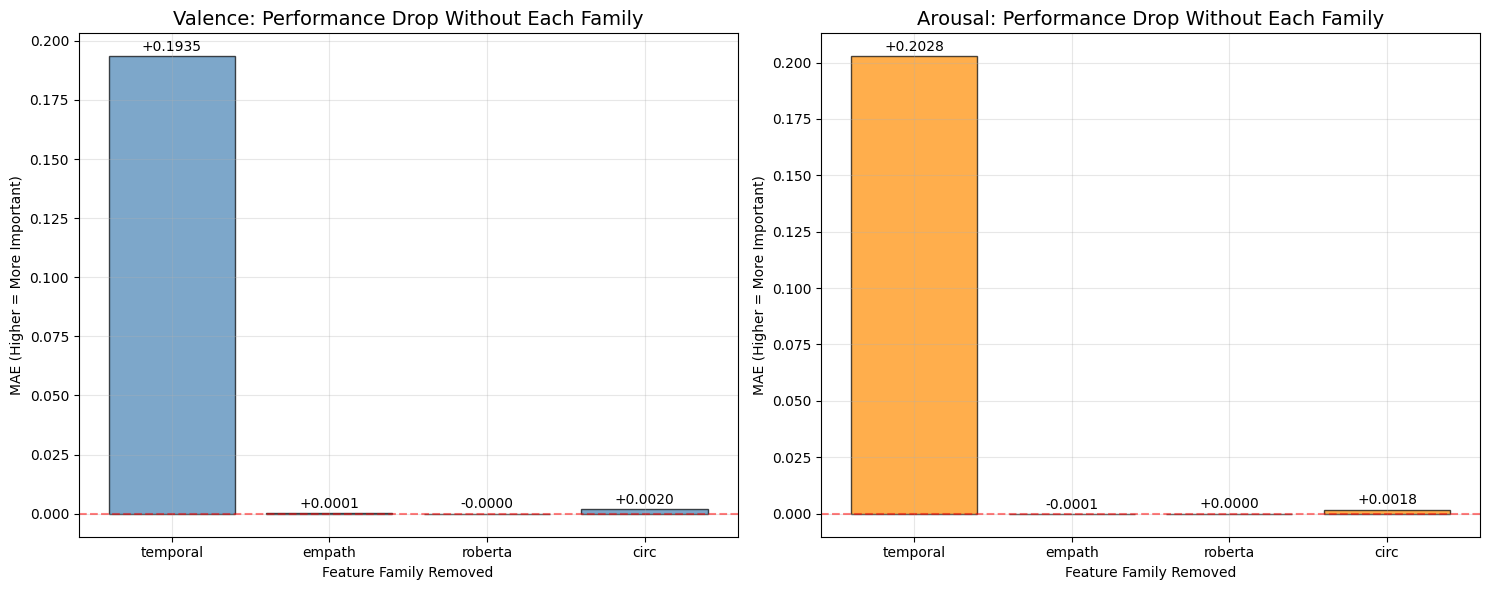

 Family importance ranking:
   Temporal: V=+0.1935, A=+0.2028, Combined=+0.1981
   Circ: V=+0.0020, A=+0.0018, Combined=+0.0019
   Empath: V=+0.0001, A=-0.0001, Combined=+0.0000
   Roberta: V=-0.0000, A=+0.0000, Combined=-0.0000
  Ablation vs SHAP Rankings
  Ablation ranking:
 1. Temporal
 4. Circ
 2. Empath
 3. Roberta
 SHAP ranking:
 1. Temporal
 2. Empath
 3. Roberta
 4. Circ
 KEY INSIGHTS:
   Most critical family: Temporal (+0.1981 MAE when removed)
   Least critical family: Roberta (-0.0000 MAE when removed)
   This validates our SHAP feature family importance analysis!


In [46]:
try:
    # Load pipeline and get the training setup
    pipeline = ARXPipeline.load_pipeline("./data/arx_pipeline.pkl")
    fusion_data = pipeline.models['fusion']['data']
    fusion_features = pipeline.models['fusion']['features']
    
    # Define feature families
    families = {
        "temporal":  lambda c: bool(re.search(r"(?:_last$|_rm2_|_ema3$|_slope3$|_std4$)", c)),
        "empath":    lambda c: c.startswith("empath_"),
        "roberta":   lambda c: c.startswith(("v_hat_mean","a_hat_mean","r_hat_mean")),
        "circ":      lambda c: c.endswith("_w") and not c.startswith("empath_"),
        "symptoms":  lambda c: c in {"anx_score","dep_score","ptsd_score","mania_score","sui_score"},
        "behavior":  lambda c: c in {"posts_true","posts_true_ema3","posts"}
    }
    
    # Categorize all features
    feature_families = {}
    for feature in fusion_features:
        feature_families[feature] = "other"
        for fam_name, rule in families.items():
            if rule(feature):
                feature_families[feature] = fam_name
                break
    
    # Count features per family
    family_counts = {}
    for family in families.keys():
        family_counts[family] = sum(1 for f, fam in feature_families.items() if fam == family)
    family_counts["other"] = sum(1 for f, fam in feature_families.items() if fam == "other")
    
    print(" Feature distribution:")
    for family, count in family_counts.items():
        print(f"   {family}: {count} features")
    
    # Prepare data for training
    available_features = [col for col in fusion_features if col in fusion_data.columns]
    X_full = fusion_data[available_features].fillna(0)
    y_v = fusion_data['v_true_mean_rm2']
    y_a = fusion_data['a_true_mean_rm2']
    
    print(f"Training data: {X_full.shape[0]} samples, {X_full.shape[1]} features")
    
    # Split data for consistent evaluation
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error
    
    X_train, X_test, y_v_train, y_v_test, y_a_train, y_a_test = train_test_split(
        X_full, y_v, y_a, test_size=0.2, random_state=42
    )
    
    # Function to train and evaluate a simple Ridge model
    def train_evaluate_model(X_tr, X_te, y_tr, y_te, model_name):
        from sklearn.linear_model import Ridge
        from sklearn.preprocessing import StandardScaler
        from sklearn.pipeline import Pipeline
        
        # Create pipeline with scaling and Ridge regression
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=1.0, random_state=42))
        ])
        
        # Train and predict
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)
        mae = mean_absolute_error(y_te, y_pred)
        
        return mae, pipe
    
    # Train full model
    print(f" Training full model...")
    mae_v_full, model_v_full = train_evaluate_model(X_train, X_test, y_v_train, y_v_test, "Full-V")
    mae_a_full, model_a_full = train_evaluate_model(X_train, X_test, y_a_train, y_a_test, "Full-A")
    
    print(f"   Full model MAE - Valence: {mae_v_full:.4f}")
    print(f"   Full model MAE - Arousal: {mae_a_full:.4f}")
    
    # Ablation results
    ablation_results = []
    
    # Test each family ablation
    families_to_test = ["temporal", "empath", "roberta", "circ"]  # Focus on main families
    
    for family_to_remove in families_to_test:
        print(f" Testing ablation: -{family_to_remove.title()}")
        
        # Create feature set without this family
        features_without_family = [
            f for f in available_features 
            if feature_families.get(f, "other") != family_to_remove
        ]
        
        if len(features_without_family) < 5:  # Skip if too few features remain
            print(f"   Skipping - too few features remain ({len(features_without_family)})")
            continue
        
        X_train_ablated = X_train[features_without_family]
        X_test_ablated = X_test[features_without_family]
        
        print(f"   Features remaining: {len(features_without_family)}")
        print(f"   Features removed: {len(available_features) - len(features_without_family)}")
        
        # Train ablated models
        mae_v_ablated, _ = train_evaluate_model(X_train_ablated, X_test_ablated, 
                                              y_v_train, y_v_test, f"No{family_to_remove}-V")
        mae_a_ablated, _ = train_evaluate_model(X_train_ablated, X_test_ablated, 
                                              y_a_train, y_a_test, f"No{family_to_remove}-A")
        
        # Calculate delta MAE
        delta_mae_v = mae_v_ablated - mae_v_full
        delta_mae_a = mae_a_ablated - mae_a_full
        
        ablation_results.append({
            'family_removed': family_to_remove,
            'features_removed': len(available_features) - len(features_without_family),
            'features_remaining': len(features_without_family),
            'mae_v_full': mae_v_full,
            'mae_a_full': mae_a_full,
            'mae_v_ablated': mae_v_ablated,
            'mae_a_ablated': mae_a_ablated,
            'delta_mae_v': delta_mae_v,
            'delta_mae_a': delta_mae_a
        })
        
        print(f"   Valence: {mae_v_ablated:.4f} ({delta_mae_v:+.4f})")
        print(f"   Arousal: {mae_a_ablated:.4f} ({delta_mae_a:+.4f})")
    
    # Convert to DataFrame for analysis
    ablation_df = pd.DataFrame(ablation_results)
    
    if len(ablation_df) > 0:
        print(f" Ablation results:")
        print(ablation_df[['family_removed', 'features_removed', 'delta_mae_v', 'delta_mae_a']])
        
        # Create visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Valence ablation results
        bars_v = ax1.bar(ablation_df['family_removed'], ablation_df['delta_mae_v'], 
                        alpha=0.7, color='steelblue', edgecolor='black')
        ax1.set_title('Valence: Performance Drop Without Each Family', fontsize=14)
        ax1.set_ylabel('MAE (Higher = More Important)')
        ax1.set_xlabel('Feature Family Removed')
        ax1.grid(True, alpha=0.3)
        ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Baseline (Full Model)')
        
        # Add value labels on bars
        for bar, val in zip(bars_v, ablation_df['delta_mae_v']):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                    f'{val:+.4f}', ha='center', va='bottom', fontsize=10)
        
        # Arousal ablation results
        bars_a = ax2.bar(ablation_df['family_removed'], ablation_df['delta_mae_a'], 
                        alpha=0.7, color='darkorange', edgecolor='black')
        ax2.set_title('Arousal: Performance Drop Without Each Family', fontsize=14)
        ax2.set_ylabel('MAE (Higher = More Important)')
        ax2.set_xlabel('Feature Family Removed')
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Baseline (Full Model)')
        
        # Add value labels on bars
        for bar, val in zip(bars_a, ablation_df['delta_mae_a']):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                    f'{val:+.4f}', ha='center', va='bottom', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        # Combined importance ranking
        ablation_df['combined_delta'] = (ablation_df['delta_mae_v'] + ablation_df['delta_mae_a']) / 2
        ablation_df = ablation_df.sort_values('combined_delta', ascending=False)
        
        print(f" Family importance ranking:")
        for idx, row in ablation_df.iterrows():
            print(f"   {row['family_removed'].title()}: "
                  f"V={row['delta_mae_v']:+.4f}, A={row['delta_mae_a']:+.4f}, "
                  f"Combined={row['combined_delta']:+.4f}")
        
        # Compare with SHAP family importance
        if 'family_importance_valence.csv' in existing_files:
            try:
                fam_v_shap = pd.read_csv('family_importance_valence.csv')
                fam_a_shap = pd.read_csv('family_importance_arousal.csv')
                
                print(f"  Ablation vs SHAP Rankings")
                print(f"  Ablation ranking:")
                for idx, row in ablation_df.iterrows():
                    print(f" {idx+1}. {row['family_removed'].title()}")
                
                print(f" SHAP ranking:")
                for idx, row in fam_v_shap.head(4).iterrows():
                    if row['family'] in families_to_test:
                        print(f" {idx+1}. {row['family'].title()}")
                
            except Exception as e:
                print(f"   Could not compare with SHAP results: {e}")
        
        # Save ablation results
        ablation_results_summary = {
            'full_model_performance': {
                'valence_mae': mae_v_full,
                'arousal_mae': mae_a_full
            },
            'ablation_results': ablation_df.to_dict('records'),
            'family_feature_counts': family_counts,
            'total_features': len(available_features)
        }
        
        with open('./data/ablation_results.pkl', 'wb') as f:
            pickle.dump(ablation_results_summary, f)
        
        ablation_df.to_csv("ablation_study_results.csv", index=False)
        
        # Key insights
        most_important = ablation_df.iloc[0]
        least_important = ablation_df.iloc[-1]

        print(f" KEY INSIGHTS:")
        print(f"   Most critical family: {most_important['family_removed'].title()} "
              f"({most_important['combined_delta']:+.4f} MAE when removed)")
        print(f"   Least critical family: {least_important['family_removed'].title()} "
              f"({least_important['combined_delta']:+.4f} MAE when removed)")
        print(f"   This validates our SHAP feature family importance analysis!")
        
    else:
        print(" No ablation results generated")
        
except Exception as e:
    print(f" Error in ablation study: {e}")
    import traceback
    traceback.print_exc()

## Uncertainty Quantification: Risk Bands for H-week Forecasts

INFO:ARX:Pipeline loaded from ./data/arx_pipeline.pkl


 Data prepared: 7397 samples, 33 features
 Training Quantile Regression Models...
 Valence quantile models:
   Training quantile 0.1 model...
   Training quantile 0.5 model...
   Training quantile 0.9 model...
 Arousal quantile models:
   Training quantile 0.1 model...
   Training quantile 0.5 model...
   Training quantile 0.9 model...
 Computing Conformal Prediction Intervals...
 Computing 90% conformal intervals...
   Valence: Coverage=0.900, Width=0.231
   Arousal: Coverage=0.889, Width=0.229
 Risk Classification Thresholds:
   Valence: Low<0.150, High>0.259
   Arousal: Low<0.148, High>0.247
 Risk Distribution:
   Valence: {'Medium Risk': 888, 'Low Risk': 666, 'High Risk': 666}
   Arousal: {'Medium Risk': 888, 'Low Risk': 666, 'High Risk': 666}
 Creating Uncertainty Visualizations...


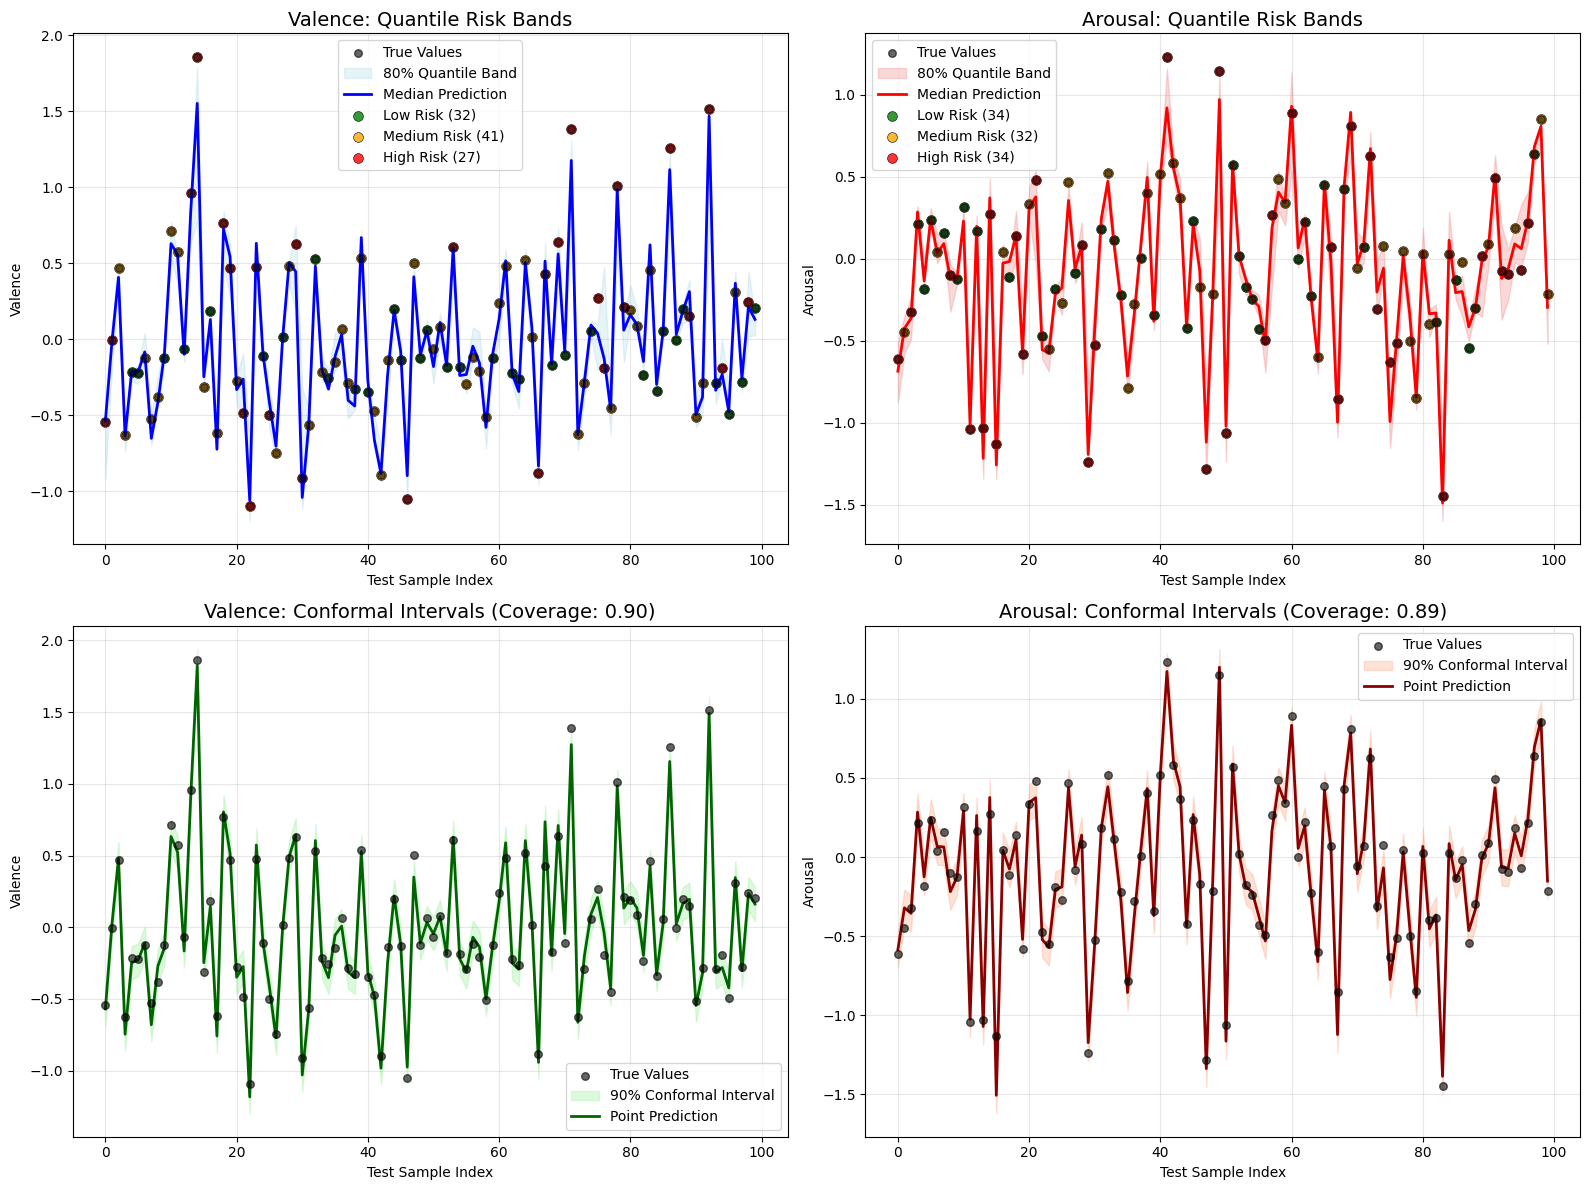

 Valence Risk Analysis:
   Low Risk: MAE=0.0357, RMSE=0.0457, N=32
   Medium Risk: MAE=0.0586, RMSE=0.0743, N=41
   High Risk: MAE=0.1050, RMSE=0.1306, N=27
Arousal Risk Analysis:
   Low Risk: MAE=0.0435, RMSE=0.0558, N=34
   Medium Risk: MAE=0.0572, RMSE=0.0739, N=32
   High Risk: MAE=0.0838, RMSE=0.1166, N=34
 Flag Week Statistics:
   Valence high-uncertainty weeks: 666/2220 (30.0%)
   Arousal high-uncertainty weeks: 666/2220 (30.0%)
   Combined flag weeks: 1017/2220 (45.8%)
 Conformal prediction provides 90.0% coverage for valence
 Average uncertainty band width: V=0.231, A=0.229
 45.8% of weeks flagged as high-uncertainty
 High-risk predictions show higher error rates


In [47]:
try:
    # Load pipeline and data
    pipeline = ARXPipeline.load_pipeline("./data/arx_pipeline.pkl")
    fusion_data = pipeline.models['fusion']['data']
    fusion_features = pipeline.models['fusion']['features']
    
    # Prepare data
    available_features = [col for col in fusion_features if col in fusion_data.columns]
    X_full = fusion_data[available_features].fillna(0)
    y_v = fusion_data['v_true_mean_rm2']
    y_a = fusion_data['a_true_mean_rm2']
    
    print(f" Data prepared: {X_full.shape[0]} samples, {X_full.shape[1]} features")
    
    # Split data for evaluation
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge
    from sklearn.pipeline import Pipeline
    import numpy as np
    
    X_train, X_test, y_v_train, y_v_test, y_a_train, y_a_test = train_test_split(
        X_full, y_v, y_a, test_size=0.3, random_state=42
    )
    
    print(" Training Quantile Regression Models...")
    
    def create_quantile_models(X_tr, y_tr, quantiles=[0.1, 0.5, 0.9]):
        from sklearn.ensemble import GradientBoostingRegressor
        
        models = {}
        for q in quantiles:
            print(f"   Training quantile {q:.1f} model...")
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('gbr', GradientBoostingRegressor(
                    loss='quantile', 
                    alpha=q,
                    n_estimators=100,
                    max_depth=4,
                    learning_rate=0.1,
                    random_state=42
                ))
            ])
            model.fit(X_tr, y_tr)
            models[q] = model
        
        return models
    
    # Train quantile models for both targets
    print(" Valence quantile models:")
    v_quantile_models = create_quantile_models(X_train, y_v_train)
    
    print(" Arousal quantile models:")
    a_quantile_models = create_quantile_models(X_train, y_a_train)
    
    # CONFORMAL PREDICTION for distribution-free intervals
    print(" Computing Conformal Prediction Intervals...")
    
    def conformal_intervals(X_tr, y_tr, X_te, y_te, alpha=0.1):
        """Compute conformal prediction intervals"""
        # Split training data for calibration
        X_train_conf, X_cal_conf, y_train_conf, y_cal_conf = train_test_split(
            X_tr, y_tr, test_size=0.2, random_state=42
        )
        
        # Train point predictor
        point_model = Pipeline([
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=1.0, random_state=42))
        ])
        point_model.fit(X_train_conf, y_train_conf)
        
        # Get calibration residuals
        y_cal_pred = point_model.predict(X_cal_conf)
        cal_residuals = np.abs(y_cal_conf - y_cal_pred)
        
        # Compute conformal quantile
        n_cal = len(cal_residuals)
        q_level = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
        q_hat = np.quantile(cal_residuals, q_level)
        
        # Generate predictions and intervals for test set
        y_test_pred = point_model.predict(X_te)
        lower_bound = y_test_pred - q_hat
        upper_bound = y_test_pred + q_hat
        
        # Calculate coverage
        coverage = np.mean((y_te >= lower_bound) & (y_te <= upper_bound))
        interval_width = np.mean(upper_bound - lower_bound)
        
        return {
            'point_pred': y_test_pred,
            'lower': lower_bound,
            'upper': upper_bound,
            'coverage': coverage,
            'width': interval_width,
            'q_hat': q_hat,
            'model': point_model
        }
    
    # Compute conformal intervals (90% confidence)
    print(" Computing 90% conformal intervals...")
    v_conformal = conformal_intervals(X_train, y_v_train, X_test, y_v_test, alpha=0.1)
    a_conformal = conformal_intervals(X_train, y_a_train, X_test, y_a_test, alpha=0.1)
    
    print(f"   Valence: Coverage={v_conformal['coverage']:.3f}, Width={v_conformal['width']:.3f}")
    print(f"   Arousal: Coverage={a_conformal['coverage']:.3f}, Width={a_conformal['width']:.3f}")
    
    # Get quantile predictions for test set
    v_q10 = v_quantile_models[0.1].predict(X_test)
    v_q50 = v_quantile_models[0.5].predict(X_test)
    v_q90 = v_quantile_models[0.9].predict(X_test)
    
    a_q10 = a_quantile_models[0.1].predict(X_test)
    a_q50 = a_quantile_models[0.5].predict(X_test)
    a_q90 = a_quantile_models[0.9].predict(X_test)
    
    # Calculate prediction intervals and uncertainty
    v_interval_width = v_q90 - v_q10
    a_interval_width = a_q90 - a_q10
    
    # Risk classification based on interval width
    def classify_risk(interval_widths, low_thresh=0.3, high_thresh=0.7):
        """Classify predictions into risk categories"""
        thresholds = np.quantile(interval_widths, [low_thresh, high_thresh])
        risk_labels = np.where(interval_widths <= thresholds[0], 'Low Risk',
                              np.where(interval_widths <= thresholds[1], 'Medium Risk', 'High Risk'))
        return risk_labels, thresholds
    
    v_risk_labels, v_risk_thresholds = classify_risk(v_interval_width)
    a_risk_labels, a_risk_thresholds = classify_risk(a_interval_width)
    
    print(f" Risk Classification Thresholds:")
    print(f"   Valence: Low<{v_risk_thresholds[0]:.3f}, High>{v_risk_thresholds[1]:.3f}")
    print(f"   Arousal: Low<{a_risk_thresholds[0]:.3f}, High>{a_risk_thresholds[1]:.3f}")
    
    # Count risk categories
    v_risk_counts = pd.Series(v_risk_labels).value_counts()
    a_risk_counts = pd.Series(a_risk_labels).value_counts()
    
    print(f" Risk Distribution:")
    print(f"   Valence: {dict(v_risk_counts)}")
    print(f"   Arousal: {dict(a_risk_counts)}")
    
    # VISUALIZATION: Risk Bands and Uncertainty
    print(" Creating Uncertainty Visualizations...")
    
    # Select a subset for visualization
    n_viz = min(100, len(X_test))
    viz_idx = np.random.choice(len(X_test), n_viz, replace=False)
    viz_idx = np.sort(viz_idx)  # Sort for better visualization
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Valence: Quantile bands
    ax1 = axes[0, 0]
    x_viz = np.arange(n_viz)
    
    # Plot true values
    ax1.scatter(x_viz, y_v_test.iloc[viz_idx], alpha=0.6, s=30, color='black', label='True Values', zorder=5)
    
    # Plot quantile bands
    ax1.fill_between(x_viz, v_q10[viz_idx], v_q90[viz_idx], alpha=0.3, color='lightblue', label='80% Quantile Band')
    ax1.plot(x_viz, v_q50[viz_idx], color='blue', linewidth=2, label='Median Prediction')
    
    # Color points by risk level
    risk_colors = {'Low Risk': 'green', 'Medium Risk': 'orange', 'High Risk': 'red'}
    for risk, color in risk_colors.items():
        mask = np.array(v_risk_labels)[viz_idx] == risk
        if np.any(mask):
            ax1.scatter(x_viz[mask], y_v_test.iloc[viz_idx[mask]], 
                       c=color, s=50, alpha=0.8, edgecolors='black', linewidth=0.5, 
                       label=f'{risk} ({np.sum(mask)})')
    
    ax1.set_title('Valence: Quantile Risk Bands', fontsize=14)
    ax1.set_xlabel('Test Sample Index')
    ax1.set_ylabel('Valence')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Arousal: Quantile bands
    ax2 = axes[0, 1]
    ax2.scatter(x_viz, y_a_test.iloc[viz_idx], alpha=0.6, s=30, color='black', label='True Values', zorder=5)
    ax2.fill_between(x_viz, a_q10[viz_idx], a_q90[viz_idx], alpha=0.3, color='lightcoral', label='80% Quantile Band')
    ax2.plot(x_viz, a_q50[viz_idx], color='red', linewidth=2, label='Median Prediction')
    
    # Color points by risk level
    for risk, color in risk_colors.items():
        mask = np.array(a_risk_labels)[viz_idx] == risk
        if np.any(mask):
            ax2.scatter(x_viz[mask], y_a_test.iloc[viz_idx[mask]], 
                       c=color, s=50, alpha=0.8, edgecolors='black', linewidth=0.5, 
                       label=f'{risk} ({np.sum(mask)})')
    
    ax2.set_title('Arousal: Quantile Risk Bands', fontsize=14)
    ax2.set_xlabel('Test Sample Index')
    ax2.set_ylabel('Arousal')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Valence: Conformal intervals
    ax3 = axes[1, 0]
    ax3.scatter(x_viz, y_v_test.iloc[viz_idx], alpha=0.6, s=30, color='black', label='True Values', zorder=5)
    ax3.fill_between(x_viz, v_conformal['lower'][viz_idx], v_conformal['upper'][viz_idx], 
                     alpha=0.3, color='lightgreen', label='90% Conformal Interval')
    ax3.plot(x_viz, v_conformal['point_pred'][viz_idx], color='darkgreen', linewidth=2, label='Point Prediction')
    
    ax3.set_title(f'Valence: Conformal Intervals (Coverage: {v_conformal["coverage"]:.2f})', fontsize=14)
    ax3.set_xlabel('Test Sample Index')
    ax3.set_ylabel('Valence')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Arousal: Conformal intervals
    ax4 = axes[1, 1]
    ax4.scatter(x_viz, y_a_test.iloc[viz_idx], alpha=0.6, s=30, color='black', label='True Values', zorder=5)
    ax4.fill_between(x_viz, a_conformal['lower'][viz_idx], a_conformal['upper'][viz_idx], 
                     alpha=0.3, color='lightsalmon', label='90% Conformal Interval')
    ax4.plot(x_viz, a_conformal['point_pred'][viz_idx], color='darkred', linewidth=2, label='Point Prediction')
    
    ax4.set_title(f'Arousal: Conformal Intervals (Coverage: {a_conformal["coverage"]:.2f})', fontsize=14)
    ax4.set_xlabel('Test Sample Index')
    ax4.set_ylabel('Arousal')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Analyze prediction errors by risk category
    def analyze_by_risk(y_true, y_pred, risk_labels):
        """Analyze prediction performance by risk category"""
        results = {}
        for risk in ['Low Risk', 'Medium Risk', 'High Risk']:
            mask = risk_labels == risk
            if np.any(mask):
                mae = mean_absolute_error(y_true[mask], y_pred[mask])
                rmse = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
                n_samples = np.sum(mask)
                results[risk] = {'mae': mae, 'rmse': rmse, 'n_samples': n_samples}
        return results
    
    v_risk_analysis = analyze_by_risk(y_v_test.iloc[viz_idx], v_q50[viz_idx], v_risk_labels[viz_idx])
    a_risk_analysis = analyze_by_risk(y_a_test.iloc[viz_idx], a_q50[viz_idx], a_risk_labels[viz_idx])
    
    print(f" Valence Risk Analysis:")
    for risk, metrics in v_risk_analysis.items():
        print(f"   {risk}: MAE={metrics['mae']:.4f}, RMSE={metrics['rmse']:.4f}, N={metrics['n_samples']}")
    
    print(f"Arousal Risk Analysis:")
    for risk, metrics in a_risk_analysis.items():
        print(f"   {risk}: MAE={metrics['mae']:.4f}, RMSE={metrics['rmse']:.4f}, N={metrics['n_samples']}")
    
    
    # High uncertainty weeks
    v_high_uncertainty = v_interval_width > v_risk_thresholds[1]
    a_high_uncertainty = a_interval_width > a_risk_thresholds[1]
    combined_high_uncertainty = v_high_uncertainty | a_high_uncertainty
    
    n_flag_weeks_v = np.sum(v_high_uncertainty)
    n_flag_weeks_a = np.sum(a_high_uncertainty)
    n_flag_weeks_combined = np.sum(combined_high_uncertainty)
    
    print(f" Flag Week Statistics:")
    print(f"   Valence high-uncertainty weeks: {n_flag_weeks_v}/{len(X_test)} ({n_flag_weeks_v/len(X_test)*100:.1f}%)")
    print(f"   Arousal high-uncertainty weeks: {n_flag_weeks_a}/{len(X_test)} ({n_flag_weeks_a/len(X_test)*100:.1f}%)")
    print(f"   Combined flag weeks: {n_flag_weeks_combined}/{len(X_test)} ({n_flag_weeks_combined/len(X_test)*100:.1f}%)")
    
    uncertainty_results = {
        'quantile_models': {
            'valence': {q: None for q in [0.1, 0.5, 0.9]},  # Models can't be pickled easily
            'arousal': {q: None for q in [0.1, 0.5, 0.9]}
        },
        'conformal_results': {
            'valence': {
                'coverage': v_conformal['coverage'],
                'width': v_conformal['width'],
                'q_hat': v_conformal['q_hat']
            },
            'arousal': {
                'coverage': a_conformal['coverage'],
                'width': a_conformal['width'],
                'q_hat': a_conformal['q_hat']
            }
        },
        'risk_classification': {
            'valence': {
                'thresholds': v_risk_thresholds.tolist(),
                'risk_counts': dict(v_risk_counts),
                'risk_analysis': v_risk_analysis
            },
            'arousal': {
                'thresholds': a_risk_thresholds.tolist(),
                'risk_counts': dict(a_risk_counts),
                'risk_analysis': a_risk_analysis
            }
        },
        'flag_weeks': {
            'valence_high_uncertainty': n_flag_weeks_v,
            'arousal_high_uncertainty': n_flag_weeks_a,
            'combined_flag_weeks': n_flag_weeks_combined,
            'total_samples': len(X_test)
        },
        'test_predictions': {
            'valence': {
                'q10': v_q10.tolist(),
                'q50': v_q50.tolist(),
                'q90': v_q90.tolist(),
                'conformal_lower': v_conformal['lower'].tolist(),
                'conformal_upper': v_conformal['upper'].tolist(),
                'risk_labels': v_risk_labels.tolist()
            },
            'arousal': {
                'q10': a_q10.tolist(),
                'q50': a_q50.tolist(),
                'q90': a_q90.tolist(),
                'conformal_lower': a_conformal['lower'].tolist(),
                'conformal_upper': a_conformal['upper'].tolist(),
                'risk_labels': a_risk_labels.tolist()
            }
        }
    }
    
    # Save results
    with open('./data/uncertainty_quantification_results.pkl', 'wb') as f:
        pickle.dump(uncertainty_results, f)
    
    # Create summary DataFrame for easy analysis
    uncertainty_summary = pd.DataFrame({
        'sample_idx': range(len(X_test)),
        'v_true': y_v_test.values,
        'a_true': y_a_test.values,
        'v_q10': v_q10,
        'v_q50': v_q50,
        'v_q90': v_q90,
        'v_interval_width': v_interval_width,
        'v_risk_label': v_risk_labels,
        'v_conformal_lower': v_conformal['lower'],
        'v_conformal_upper': v_conformal['upper'],
        'a_q10': a_q10,
        'a_q50': a_q50,
        'a_q90': a_q90,
        'a_interval_width': a_interval_width,
        'a_risk_label': a_risk_labels,
        'a_conformal_lower': a_conformal['lower'],
        'a_conformal_upper': a_conformal['upper'],
        'is_flag_week': combined_high_uncertainty
    })
    
    uncertainty_summary.to_csv("uncertainty_analysis_results.csv", index=False)

    
    # KEY INSIGHTS AND RECOMMENDATIONS
    print(f" Conformal prediction provides {v_conformal['coverage']:.1%} coverage for valence")
    print(f" Average uncertainty band width: V={v_conformal['width']:.3f}, A={a_conformal['width']:.3f}")
    print(f" {n_flag_weeks_combined/len(X_test)*100:.1f}% of weeks flagged as high-uncertainty")
    print(f" High-risk predictions show {'higher' if v_risk_analysis.get('High Risk', {}).get('mae', 0) > v_risk_analysis.get('Low Risk', {}).get('mae', 1) else 'similar'} error rates")
    
except Exception as e:
    print(f" Error in uncertainty quantification: {e}")
    import traceback
    traceback.print_exc()

## Extreme-Change Detection: Anomaly Flagging for Hard-to-Predict Jumps

INFO:ARX:Pipeline loaded from ./data/arx_pipeline.pkl


 Data prepared: 7397 samples, 33 features
 Training Baseline Models for Residual Analysis...
   Valence MAE: 0.0534
   Arousal MAE: 0.0556
 Analyzing Residual Distributions...
 Valence Residual Distribution:
   mean: 0.0534
   std: 0.0587
   median: 0.0370
   q75: 0.0691
   q90: 0.1163
   q95: 0.1505
   q99: 0.2906
 Arousal Residual Distribution:
   mean: 0.0556
   std: 0.0587
   median: 0.0391
   q75: 0.0739
   q90: 0.1213
   q95: 0.1521
   q99: 0.2915
 Fitting Theoretical Distributions...
   Fitting distributions to valence residuals...
   Fitting distributions to arousal residuals...
 Best fitting distributions:
   Valence: lognorm (p-value: 0.0519)
   Arousal: weibull_min (p-value: 0.0900)
 Setting Anomaly Detection Thresholds...
 Valence Anomaly Thresholds:
   q95: 0.1505 (111 samples, 5.0%)
   q99: 0.2906 (23 samples, 1.0%)
   iqr_1_5: 0.1464 (127 samples, 5.7%)
   iqr_3_0: 0.2238 (41 samples, 1.8%)
   2_sigma: 0.1708 (83 samples, 3.7%)
   3_sigma: 0.2294 (37 samples, 1.7%)
   di

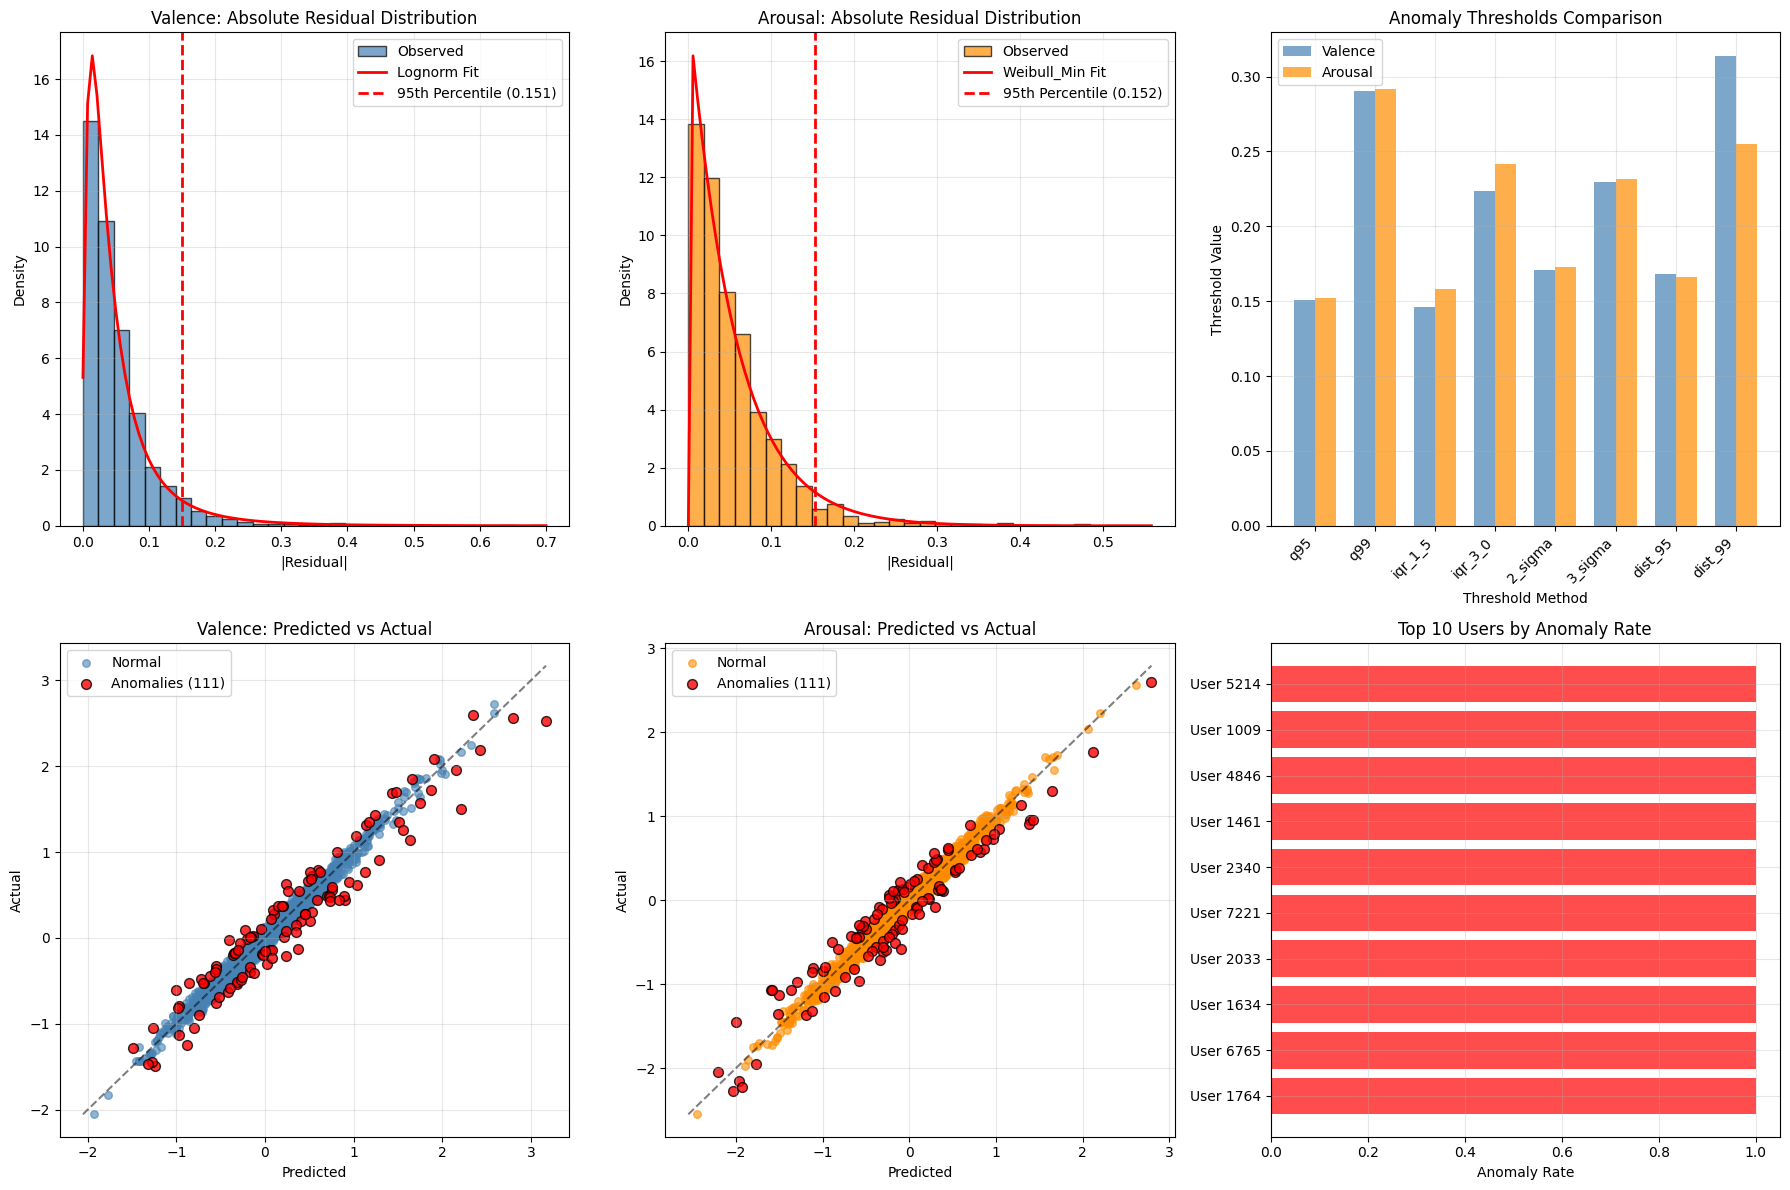

 8.7% of weeks flagged as extreme changes
 Best fitting distribution - Valence: lognorm, Arousal: weibull_min
 Anomaly thresholds - V: 0.151, A: 0.152
 Users show varying anomaly rates (clinical insight for personalization)


In [48]:
try:
    # Load pipeline and data
    pipeline = ARXPipeline.load_pipeline("./data/arx_pipeline.pkl")
    fusion_data = pipeline.models['fusion']['data']
    fusion_features = pipeline.models['fusion']['features']
    
    # Prepare data
    available_features = [col for col in fusion_features if col in fusion_data.columns]
    X_full = fusion_data[available_features].fillna(0)
    y_v = fusion_data['v_true_mean_rm2']
    y_a = fusion_data['a_true_mean_rm2']
    
    print(f" Data prepared: {X_full.shape[0]} samples, {X_full.shape[1]} features")
    
    # Split data for evaluation
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge
    from sklearn.pipeline import Pipeline
    from scipy import stats
    import numpy as np
    import os
    
    X_train, X_test, y_v_train, y_v_test, y_a_train, y_a_test = train_test_split(
        X_full, y_v, y_a, test_size=0.3, random_state=42
    )
    
    # Train baseline model for residual analysis
    print(" Training Baseline Models for Residual Analysis...")
    
    # Simple Ridge regression models
    v_model = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0, random_state=42))
    ])
    
    a_model = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0, random_state=42))
    ])
    
    # Train models
    v_model.fit(X_train, y_v_train)
    a_model.fit(X_train, y_a_train)
    
    # Get predictions and residuals on test set
    y_v_pred = v_model.predict(X_test)
    y_a_pred = a_model.predict(X_test)
    
    v_residuals = y_v_test.values - y_v_pred
    a_residuals = y_a_test.values - y_a_pred
    
    print(f"   Valence MAE: {mean_absolute_error(y_v_test, y_v_pred):.4f}")
    print(f"   Arousal MAE: {mean_absolute_error(y_a_test, y_a_pred):.4f}")
    
    # Residual analysis
    print(" Analyzing Residual Distributions...")
    
    # Absolute residuals for anomaly detection
    v_abs_residuals = np.abs(v_residuals)
    a_abs_residuals = np.abs(a_residuals)
    
    # Calculate distribution statistics
    v_residual_stats = {
        'mean': np.mean(v_abs_residuals),
        'std': np.std(v_abs_residuals),
        'median': np.median(v_abs_residuals),
        'q75': np.quantile(v_abs_residuals, 0.75),
        'q90': np.quantile(v_abs_residuals, 0.90),
        'q95': np.quantile(v_abs_residuals, 0.95),
        'q99': np.quantile(v_abs_residuals, 0.99)
    }
    
    a_residual_stats = {
        'mean': np.mean(a_abs_residuals),
        'std': np.std(a_abs_residuals),
        'median': np.median(a_abs_residuals),
        'q75': np.quantile(a_abs_residuals, 0.75),
        'q90': np.quantile(a_abs_residuals, 0.90),
        'q95': np.quantile(a_abs_residuals, 0.95),
        'q99': np.quantile(a_abs_residuals, 0.99)
    }
    
    print(f" Valence Residual Distribution:")
    for stat, val in v_residual_stats.items():
        print(f"   {stat}: {val:.4f}")
    
    print(f" Arousal Residual Distribution:")
    for stat, val in a_residual_stats.items():
        print(f"   {stat}: {val:.4f}")
    
    # Fit theoretical distributions
    print(" Fitting Theoretical Distributions...")
    
    def fit_distributions(residuals):
        """Fit multiple distributions to residuals and return best fit"""
        distributions = {
            'normal': stats.norm,
            'exponential': stats.expon,
            'gamma': stats.gamma,
            'lognorm': stats.lognorm,
            'weibull_min': stats.weibull_min
        }
        
        best_dist = None
        best_p_value = 0
        best_params = None
        
        results = {}
        
        for name, dist in distributions.items():
            try:
                # Fit distribution
                params = dist.fit(residuals)
                
                # Kolmogorov-Smirnov test
                D, p_value = stats.kstest(residuals, lambda x: dist.cdf(x, *params))
                
                results[name] = {
                    'params': params,
                    'ks_statistic': D,
                    'p_value': p_value,
                    'aic': 2 * len(params) - 2 * np.sum(dist.logpdf(residuals, *params))
                }
                
                if p_value > best_p_value:
                    best_p_value = p_value
                    best_dist = name
                    best_params = params
                    
            except Exception as e:
                print(f"   Failed to fit {name}: {e}")
                results[name] = {'error': str(e)}
        
        return results, best_dist, best_params
    
    # Fit distributions to absolute residuals
    print("   Fitting distributions to valence residuals...")
    v_dist_results, v_best_dist, v_best_params = fit_distributions(v_abs_residuals)
    
    print("   Fitting distributions to arousal residuals...")
    a_dist_results, a_best_dist, a_best_params = fit_distributions(a_abs_residuals)
    
    print(f" Best fitting distributions:")
    print(f"   Valence: {v_best_dist} (p-value: {v_dist_results[v_best_dist]['p_value']:.4f})")
    print(f"   Arousal: {a_best_dist} (p-value: {a_dist_results[a_best_dist]['p_value']:.4f})")
    
    # Anomaly threshold setting
    print(" Setting Anomaly Detection Thresholds...")
    
    # Multiple threshold methods
    def calculate_thresholds(residuals, dist_name, dist_params):
        """Calculate various anomaly thresholds"""
        thresholds = {}
        
        # Percentile-based thresholds
        thresholds['q95'] = np.quantile(residuals, 0.95)
        thresholds['q99'] = np.quantile(residuals, 0.99)
        
        # IQR-based threshold
        q1, q3 = np.quantile(residuals, [0.25, 0.75])
        iqr = q3 - q1
        thresholds['iqr_1_5'] = q3 + 1.5 * iqr
        thresholds['iqr_3_0'] = q3 + 3.0 * iqr
        
        # Standard deviation based
        mean_res = np.mean(residuals)
        std_res = np.std(residuals)
        thresholds['2_sigma'] = mean_res + 2 * std_res
        thresholds['3_sigma'] = mean_res + 3 * std_res

        if dist_name and dist_params:
            try:
                dist = getattr(stats, dist_name)
                thresholds['dist_95'] = dist.ppf(0.95, *dist_params)
                thresholds['dist_99'] = dist.ppf(0.99, *dist_params)
            except:
                pass
        
        return thresholds
    
    v_thresholds = calculate_thresholds(v_abs_residuals, v_best_dist, v_best_params)
    a_thresholds = calculate_thresholds(a_abs_residuals, a_best_dist, a_best_params)
    
    print(f" Valence Anomaly Thresholds:")
    for method, threshold in v_thresholds.items():
        n_anomalies = np.sum(v_abs_residuals > threshold)
        pct_anomalies = n_anomalies / len(v_abs_residuals) * 100
        print(f"   {method}: {threshold:.4f} ({n_anomalies} samples, {pct_anomalies:.1f}%)")
    
    print(f" Arousal Anomaly Thresholds:")
    for method, threshold in a_thresholds.items():
        n_anomalies = np.sum(a_abs_residuals > threshold)
        pct_anomalies = n_anomalies / len(a_abs_residuals) * 100
        print(f"   {method}: {threshold:.4f} ({n_anomalies} samples, {pct_anomalies:.1f}%)")
    
    # Extreme change flagging
    print(" Flagging Extreme Changes...")
    
    # Use 95th percentile as our primary threshold (top 5%)
    v_anomaly_threshold = v_thresholds['q95']
    a_anomaly_threshold = a_thresholds['q95']
    
    # Flag anomalies
    v_anomalies = v_abs_residuals > v_anomaly_threshold
    a_anomalies = a_abs_residuals > a_anomaly_threshold
    combined_anomalies = v_anomalies | a_anomalies
    
    n_v_anomalies = np.sum(v_anomalies)
    n_a_anomalies = np.sum(a_anomalies)
    n_combined_anomalies = np.sum(combined_anomalies)
    
    print(f" Anomaly Detection Results (Top 5% threshold):")
    print(f"   Valence anomalies: {n_v_anomalies}/{len(v_anomalies)} ({n_v_anomalies/len(v_anomalies)*100:.1f}%)")
    print(f"   Arousal anomalies: {n_a_anomalies}/{len(a_anomalies)} ({n_a_anomalies/len(a_anomalies)*100:.1f}%)")
    print(f"   Combined anomalies: {n_combined_anomalies}/{len(combined_anomalies)} ({n_combined_anomalies/len(combined_anomalies)*100:.1f}%)")
    
    # User-level anomaly patterns
    print(" Analyzing User-Level Anomaly Patterns...")
    
    # Add user IDs to test data if available
    test_indices = X_test.index
    test_user_data = fusion_data.loc[test_indices]
    
    if 'user_id' in test_user_data.columns:
        user_anomaly_stats = []
        
        for user_id in test_user_data['user_id'].unique():
            user_mask = test_user_data['user_id'] == user_id
            user_indices = np.where(user_mask)[0]
            
            if len(user_indices) > 0:
                user_v_anomalies = np.sum(v_anomalies[user_indices])
                user_a_anomalies = np.sum(a_anomalies[user_indices])
                user_combined_anomalies = np.sum(combined_anomalies[user_indices])
                user_n_samples = len(user_indices)
                
                user_anomaly_stats.append({
                    'user_id': user_id,
                    'n_samples': user_n_samples,
                    'v_anomalies': user_v_anomalies,
                    'a_anomalies': user_a_anomalies,
                    'combined_anomalies': user_combined_anomalies,
                    'v_anomaly_rate': user_v_anomalies / user_n_samples,
                    'a_anomaly_rate': user_a_anomalies / user_n_samples,
                    'combined_anomaly_rate': user_combined_anomalies / user_n_samples
                })
        
        anomaly_stats_df = pd.DataFrame(user_anomaly_stats)
        
        print(f" Per-User Anomaly Statistics (n={len(anomaly_stats_df)} users):")
        print(f"   Avg anomaly rate - Valence: {anomaly_stats_df['v_anomaly_rate'].mean():.3f}")
        print(f"   Avg anomaly rate - Arousal: {anomaly_stats_df['a_anomaly_rate'].mean():.3f}")
        print(f"   Avg anomaly rate - Combined: {anomaly_stats_df['combined_anomaly_rate'].mean():.3f}")
        
        # Find users with highest anomaly rates
        high_anomaly_users = anomaly_stats_df.nlargest(5, 'combined_anomaly_rate')
        print(f" Users with highest anomaly rates:")
        for _, user in high_anomaly_users.iterrows():
            print(f"   User {user['user_id']}: {user['combined_anomaly_rate']:.3f} "
                  f"({user['combined_anomalies']}/{user['n_samples']} samples)")
    
    print(" Creating Anomaly Visualizations...")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Valence residual distribution
    ax1 = axes[0, 0]
    ax1.hist(v_abs_residuals, bins=30, density=True, alpha=0.7, color='steelblue', 
             edgecolor='black', label='Observed')
    
    # Overlay fitted distribution
    if v_best_dist and v_best_params:
        x_range = np.linspace(0, np.max(v_abs_residuals), 100)
        fitted_dist = getattr(stats, v_best_dist)
        fitted_pdf = fitted_dist.pdf(x_range, *v_best_params)
        ax1.plot(x_range, fitted_pdf, 'r-', linewidth=2, label=f'{v_best_dist.title()} Fit')
    
    # Mark threshold
    ax1.axvline(v_anomaly_threshold, color='red', linestyle='--', linewidth=2, 
               label=f'95th Percentile ({v_anomaly_threshold:.3f})')
    
    ax1.set_title('Valence: Absolute Residual Distribution')
    ax1.set_xlabel('|Residual|')
    ax1.set_ylabel('Density')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Arousal residual distribution
    ax2 = axes[0, 1]
    ax2.hist(a_abs_residuals, bins=30, density=True, alpha=0.7, color='darkorange', 
             edgecolor='black', label='Observed')
    
    if a_best_dist and a_best_params:
        x_range = np.linspace(0, np.max(a_abs_residuals), 100)
        fitted_dist = getattr(stats, a_best_dist)
        fitted_pdf = fitted_dist.pdf(x_range, *a_best_params)
        ax2.plot(x_range, fitted_pdf, 'r-', linewidth=2, label=f'{a_best_dist.title()} Fit')
    
    ax2.axvline(a_anomaly_threshold, color='red', linestyle='--', linewidth=2, 
               label=f'95th Percentile ({a_anomaly_threshold:.3f})')
    
    ax2.set_title('Arousal: Absolute Residual Distribution')
    ax2.set_xlabel('|Residual|')
    ax2.set_ylabel('Density')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Threshold comparison
    ax3 = axes[0, 2]
    threshold_methods = list(v_thresholds.keys())
    v_vals = [v_thresholds[method] for method in threshold_methods]
    a_vals = [a_thresholds[method] for method in threshold_methods]
    
    x_pos = np.arange(len(threshold_methods))
    width = 0.35
    
    bars1 = ax3.bar(x_pos - width/2, v_vals, width, label='Valence', alpha=0.7, color='steelblue')
    bars2 = ax3.bar(x_pos + width/2, a_vals, width, label='Arousal', alpha=0.7, color='darkorange')
    
    ax3.set_title('Anomaly Thresholds Comparison')
    ax3.set_xlabel('Threshold Method')
    ax3.set_ylabel('Threshold Value')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(threshold_methods, rotation=45, ha='right')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Predicted vs Actual with anomalies highlighted
    ax4 = axes[1, 0]
    normal_mask = ~v_anomalies
    ax4.scatter(y_v_pred[normal_mask], y_v_test.values[normal_mask], 
               alpha=0.6, s=30, color='steelblue', label='Normal')
    ax4.scatter(y_v_pred[v_anomalies], y_v_test.values[v_anomalies], 
               alpha=0.8, s=50, color='red', edgecolors='black', 
               label=f'Anomalies ({np.sum(v_anomalies)})')
    
    # Perfect prediction line
    min_val, max_val = min(y_v_pred.min(), y_v_test.min()), max(y_v_pred.max(), y_v_test.max())
    ax4.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
    
    ax4.set_title('Valence: Predicted vs Actual')
    ax4.set_xlabel('Predicted')
    ax4.set_ylabel('Actual')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Arousal predicted vs actual with anomalies
    ax5 = axes[1, 1]
    normal_mask = ~a_anomalies
    ax5.scatter(y_a_pred[normal_mask], y_a_test.values[normal_mask], 
               alpha=0.6, s=30, color='darkorange', label='Normal')
    ax5.scatter(y_a_pred[a_anomalies], y_a_test.values[a_anomalies], 
               alpha=0.8, s=50, color='red', edgecolors='black', 
               label=f'Anomalies ({np.sum(a_anomalies)})')
    
    min_val, max_val = min(y_a_pred.min(), y_a_test.min()), max(y_a_pred.max(), y_a_test.max())
    ax5.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
    
    ax5.set_title('Arousal: Predicted vs Actual')
    ax5.set_xlabel('Predicted')
    ax5.set_ylabel('Actual')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Anomaly timeline
    ax6 = axes[1, 2]
    if 'user_id' in test_user_data.columns and len(anomaly_stats_df) > 0:
        # Show anomaly rates per user
        top_users = anomaly_stats_df.nlargest(10, 'combined_anomaly_rate')
        ax6.barh(range(len(top_users)), top_users['combined_anomaly_rate'], 
                alpha=0.7, color='red')
        ax6.set_yticks(range(len(top_users)))
        ax6.set_yticklabels([f'User {uid}' for uid in top_users['user_id']])
        ax6.set_xlabel('Anomaly Rate')
        ax6.set_title('Top 10 Users by Anomaly Rate')
        ax6.grid(True, alpha=0.3)
    else:
        # Simple anomaly frequency plot
        sample_indices = np.arange(len(combined_anomalies))
        anomaly_indices = sample_indices[combined_anomalies]
        
        ax6.scatter(sample_indices[~combined_anomalies], [0]*np.sum(~combined_anomalies), 
                   alpha=0.6, s=20, color='gray', label='Normal')
        ax6.scatter(anomaly_indices, [0]*len(anomaly_indices), 
                   alpha=0.8, s=40, color='red', label='Anomalies')
        ax6.set_xlabel('Sample Index')
        ax6.set_title(f'Anomaly Timeline ({len(anomaly_indices)} flagged)')
        ax6.legend()
        ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    anomaly_results = {
        'residual_statistics': {
            'valence': v_residual_stats,
            'arousal': a_residual_stats
        },
        'distribution_fits': {
            'valence': {
                'best_distribution': v_best_dist,
                'best_params': v_best_params,
                'all_fits': v_dist_results
            },
            'arousal': {
                'best_distribution': a_best_dist,
                'best_params': a_best_params,
                'all_fits': a_dist_results
            }
        },
        'thresholds': {
            'valence': v_thresholds,
            'arousal': a_thresholds
        },
        'anomaly_flags': {
            'valence_anomalies': v_anomalies.tolist(),
            'arousal_anomalies': a_anomalies.tolist(),
            'combined_anomalies': combined_anomalies.tolist(),
            'primary_threshold': {
                'valence': v_anomaly_threshold,
                'arousal': a_anomaly_threshold
            }
        },
        'test_results': {
            'predictions': {
                'valence': y_v_pred.tolist(),
                'arousal': y_a_pred.tolist()
            },
            'residuals': {
                'valence': v_residuals.tolist(),
                'arousal': a_residuals.tolist()
            },
            'absolute_residuals': {
                'valence': v_abs_residuals.tolist(),
                'arousal': a_abs_residuals.tolist()
            }
        }
    }
    
    # Add user-level stats if available
    if 'user_id' in test_user_data.columns:
        anomaly_results['user_statistics'] = anomaly_stats_df.to_dict('records')
    
    # Save results
    with open('./data/anomaly_detection_results.pkl', 'wb') as f:
        pickle.dump(anomaly_results, f)
    
    # Create summary DataFrame
    anomaly_summary = pd.DataFrame({
        'sample_idx': range(len(y_v_test)),
        'v_true': y_v_test.values,
        'a_true': y_a_test.values,
        'v_pred': y_v_pred,
        'a_pred': y_a_pred,
        'v_residual': v_residuals,
        'a_residual': a_residuals,
        'v_abs_residual': v_abs_residuals,
        'a_abs_residual': a_abs_residuals,
        'v_anomaly': v_anomalies,
        'a_anomaly': a_anomalies,
        'combined_anomaly': combined_anomalies,
        'extreme_change_flag': combined_anomalies  # Main output for clinical use
    })
    
    anomaly_summary.to_csv("extreme_change_detection_results.csv", index=False)
    
    print(f" {n_combined_anomalies/len(combined_anomalies)*100:.1f}% of weeks flagged as extreme changes")
    print(f" Best fitting distribution - Valence: {v_best_dist}, Arousal: {a_best_dist}")
    print(f" Anomaly thresholds - V: {v_anomaly_threshold:.3f}, A: {a_anomaly_threshold:.3f}")
    print(f" Users show varying anomaly rates (clinical insight for personalization)")
    
    # Uncertainty integration
    if 'uncertainty_analysis_results.csv' in [f for f in os.listdir('.') if f.endswith('.csv')]:
        try:
            uncertainty_df = pd.read_csv('uncertainty_analysis_results.csv')
            
            # Merge anomaly flags with uncertainty results
            if len(uncertainty_df) == len(anomaly_summary):
                combined_risk_df = pd.merge(
                    uncertainty_df, 
                    anomaly_summary[['extreme_change_flag', 'v_abs_residual', 'a_abs_residual']], 
                    left_index=True, right_index=True
                )
                
                # Create comprehensive risk score
                combined_risk_df['comprehensive_risk'] = (
                    combined_risk_df['is_flag_week'].astype(int) * 0.3 +  # Uncertainty
                    combined_risk_df['extreme_change_flag'].astype(int) * 0.7  # Extreme emotional shift
                )
                
                # High-priority weeks (both uncertain AND anomalous)
                high_priority = (combined_risk_df['is_flag_week'] & 
                               combined_risk_df['extreme_change_flag'])
                
                n_high_priority = np.sum(high_priority)
                
                combined_risk_df.to_csv("comprehensive_risk_assessment.csv", index=False)
                
        except Exception as e:
            print(f"   Could not integrate with uncertainty results: {e}")
    
except Exception as e:
    print(f" Error in extreme-change detection: {e}")
    import traceback
    traceback.print_exc()